# 🏥 IUI Outcome Prediction: Model Training and Explainability

### Setup and Utility Functions

In [2]:
from pathlib import Path
import re
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE, ADASYN

import shap

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"


def clean_column_names(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [
        re.sub(r"[\[\]<>]", "_", str(col)).replace(" ", "_")
        for col in df.columns
    ]
    return df


def find_optimal_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    thresholds = np.clip(thresholds, 0, 1)
    j_scores = tpr - fpr
    return float(thresholds[np.argmax(j_scores)])


def calculate_net_benefit(y_true, y_prob, threshold):
    if threshold <= 0 or threshold >= 1:
        return np.nan

    tp = np.logical_and(y_true == 1, y_prob >= threshold).sum()
    fp = np.logical_and(y_true == 0, y_prob >= threshold).sum()
    n = len(y_true)

    return (tp / n) - (fp / n) * (threshold / (1 - threshold))


def plot_confusion_matrix(
    y_true,
    y_pred,
    model_name,
    threshold,
    outdir=None,
):
    if outdir is None:
        outdir = FIGURE_DIR / "confusion_matrices"
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Non-Preg", "Preg"],
        yticklabels=["Non-Preg", "Preg"]
    )
    plt.title(f"{model_name} (threshold={threshold:.3f})")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.savefig(outdir / f"{model_name}_cm.png")
    plt.close()


def plot_roc_curve(
    y_true,
    y_prob,
    model_name,
    auc_score,
    best_threshold,
    outdir=None,
):
    if outdir is None:
        outdir = FIGURE_DIR / "roc_curves"
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    thresholds = np.clip(thresholds, 0, 1)

    best_idx = np.argmin(np.abs(thresholds - best_threshold))
    best_fpr, best_tpr = fpr[best_idx], tpr[best_idx]

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, lw=2, label=f"AUC = {auc_score:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")

    plt.scatter(
        best_fpr,
        best_tpr,
        s=80,
        label=f"threshold={best_threshold:.2f}"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(model_name)
    plt.legend()
    plt.tight_layout()
    plt.savefig(outdir / f"{model_name}_roc.png")
    plt.close()


print("Setup complete")

Setup complete


### Data Preprocessing and Train-Test Splitting

In [3]:
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.impute import SimpleImputer

PROJECT_ROOT = Path.cwd().parent  
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "cycle_level_features.csv"

df = pd.read_csv(DATA_PATH)
df = clean_column_names(df)
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]

if 'Date' in df.columns:
    df = df.drop(columns=['Date'])

if 'Result' not in df.columns:
    raise ValueError("Target column 'Result' not found.")

df['Result'] = pd.to_numeric(df['Result'], errors='coerce')
df = df.dropna(subset=['Result'])

valid_target = {0, 1, 0.0, 1.0}
bad_vals = sorted(set(df['Result'].dropna().unique()) - valid_target)
if bad_vals:
    raise ValueError(f"Unexpected values in Result: {bad_vals}")

df['Result'] = df['Result'].astype(int)

object_cols = df.select_dtypes(include=['object']).columns
for c in object_cols:
    if c not in ['HN', 'Result']:
        df[c] = pd.to_numeric(df[c], errors='coerce')

print("Remaining object columns:", df.select_dtypes(include=['object']).columns.tolist())

if 'HN' not in df.columns:
    raise ValueError("Column 'HN' is required for group split.")

df = df.dropna(subset=['HN'])
df['HN'] = df['HN'].astype(str).str.strip()
df = df[df['HN'] != ""]

X_full = df.drop(columns=['Result'], errors='ignore')
y_full = df['Result'].copy()
groups = df['HN']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_full, y_full, groups=groups))

X_train = X_full.iloc[train_idx].copy()
X_test  = X_full.iloc[test_idx].copy()
y_train = y_full.iloc[train_idx].copy()
y_test  = y_full.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx].copy()
groups_test  = groups.iloc[test_idx].copy()

keep_cols = [c for c in ['HN', 'Cycle_Number'] if c in X_test.columns]
test_info = X_test[keep_cols].copy() if keep_cols else pd.DataFrame(index=X_test.index)

cols_to_impute = [c for c in X_train.columns if c != 'HN']

all_nan_cols = [c for c in cols_to_impute if X_train[c].isna().all()]
if all_nan_cols:
    print("Dropping all-NaN columns:", all_nan_cols)
    X_train = X_train.drop(columns=all_nan_cols, errors='ignore')
    X_test  = X_test.drop(columns=all_nan_cols, errors='ignore')

cols_to_impute = [c for c in X_train.columns if c != 'HN']

imputer = SimpleImputer(strategy='median')

X_train_num = pd.DataFrame(
    imputer.fit_transform(X_train[cols_to_impute]),
    columns=cols_to_impute,
    index=X_train.index
)

X_test_num = pd.DataFrame(
    imputer.transform(X_test[cols_to_impute]),
    columns=cols_to_impute,
    index=X_test.index
)

X_train_num['HN'] = X_train['HN'].values
X_test_num['HN']  = X_test['HN'].values

train_hn = set(X_train_num['HN'])
test_hn  = set(X_test_num['HN'])
overlap  = train_hn.intersection(test_hn)

print("HN overlap train/test:", len(overlap))
assert len(overlap) == 0, "Patient leakage detected"

X_train = X_train_num.drop(columns=['HN'])
X_test  = X_test_num.drop(columns=['HN'])

for col in ['Date', 'HN', 'Result']:
    assert col not in X_train.columns
    assert col not in X_test.columns

suspicious = [c for c in X_train.columns if 'result' in c.lower() or 'outcome' in c.lower()]
if suspicious:
    raise ValueError(f"Potential leakage columns: {suspicious}")

print(f'\nEvent rate full:  {y_full.mean():.4f}')
print(f'Event rate train: {y_train.mean():.4f}')
print(f'Event rate test:  {y_test.mean():.4f}')

print(f'\nSplit done. Train: {len(X_train)}, Test: {len(X_test)}')
print(f'Number of features: {X_train.shape[1]}')
print("Train positives:", int(y_train.sum()), "out of", len(y_train))
print("Test positives:",  int(y_test.sum()),  "out of", len(y_test))

Remaining object columns: ['HN']
HN overlap train/test: 0

Event rate full:  0.0621
Event rate train: 0.0605
Event rate test:  0.0687

Split done. Train: 2348, Test: 597
Number of features: 66
Train positives: 142 out of 2348
Test positives: 41 out of 597


### Model Development, Imbalance Handling, and Evaluation

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GroupKFold, RandomizedSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    accuracy_score, precision_score, recall_score, f1_score
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

import joblib
import pandas as pd


MODEL_DIR = PROJECT_ROOT / "models" / "saved_models"
REPORT_DIR = PROJECT_ROOT / "reports" / "tables"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

results_list = []
trained_models = {}

pos_weight = float((len(y_train) - y_train.sum()) / max(y_train.sum(), 1))
group_cv = GroupKFold(n_splits=3)

n_iter_map = {
    'LogisticRegression': 4,
    'RandomForest': 8,
    'XGBoost': 20,
    'CatBoost': 30,
    'LightGBM': 20,
    'MLP': 4
}

samplers = {
    'Baseline_NoResampling': None,
    'SMOTE': SMOTE(random_state=42),
    'ADASYN': ADASYN(random_state=42),
    'BorderlineSMOTE': BorderlineSMOTE(random_state=42),
    'SMOTETomek': SMOTETomek(random_state=42)
}

model_names = ['LogisticRegression', 'RandomForest', 'XGBoost', 'CatBoost', 'LightGBM', 'MLP']

for s_name, sampler in samplers.items():
    print(f"\n===== Imbalance Method: {s_name} =====")

    for m_name in model_names:
        print(f"  Training {m_name}...")

        sampler_copy = clone(sampler) if sampler is not None else None

        if m_name == 'LogisticRegression':
            if sampler_copy is None:
                estimator = ImbPipeline([
                    ('scaler', StandardScaler()),
                    ('model', LogisticRegression(
                        class_weight='balanced',
                        random_state=42,
                        max_iter=2000
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('scaler', StandardScaler()),
                    ('sampler', sampler_copy),
                    ('model', LogisticRegression(
                        class_weight=None,
                        random_state=42,
                        max_iter=2000
                    ))
                ])
            params = {'model__C': [0.01, 0.1, 1, 10]}

        elif m_name == 'RandomForest':
            if sampler_copy is None:
                estimator = ImbPipeline([
                    ('model', RandomForestClassifier(
                        random_state=42,
                        class_weight='balanced'
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('sampler', sampler_copy),
                    ('model', RandomForestClassifier(
                        random_state=42,
                        class_weight=None
                    ))
                ])
            params = {
                'model__n_estimators': [100, 200, 300],
                'model__max_depth': [5, 10, 20, None],
                'model__min_samples_leaf': [1, 2, 5]
            }

        elif m_name == 'XGBoost':
            if sampler_copy is None:
                estimator = ImbPipeline([
                    ('model', XGBClassifier(
                        random_state=42,
                        eval_metric='logloss',
                        scale_pos_weight=pos_weight
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('sampler', sampler_copy),
                    ('model', XGBClassifier(
                        random_state=42,
                        eval_metric='logloss',
                        scale_pos_weight=1.0
                    ))
                ])
            params = {
                'model__n_estimators': [100, 200, 300],
                'model__learning_rate': [0.005, 0.01, 0.05, 0.1],
                'model__max_depth': [2, 3, 4, 5],
                'model__subsample': [0.8, 1.0],
                'model__colsample_bytree': [0.8, 1.0]
            }

        elif m_name == 'CatBoost':
            if sampler_copy is None:
                estimator = ImbPipeline([
                    ('model', CatBoostClassifier(
                        random_state=42,
                        verbose=0,
                        auto_class_weights='Balanced'
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('sampler', sampler_copy),
                    ('model', CatBoostClassifier(
                        random_state=42,
                        verbose=0
                    ))
                ])
            params = {
                'model__iterations': [100, 200, 300, 500],
                'model__depth': [3, 4, 5, 6],
                'model__learning_rate': [0.005, 0.01, 0.05, 0.1],
                'model__l2_leaf_reg': [1, 3, 5, 10]
            }

        elif m_name == 'LightGBM':
            if sampler_copy is None:
                estimator = ImbPipeline([
                    ('model', LGBMClassifier(
                        random_state=42,
                        class_weight='balanced',
                        verbose=-1
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('sampler', sampler_copy),
                    ('model', LGBMClassifier(
                        random_state=42,
                        class_weight=None,
                        verbose=-1
                    ))
                ])
            params = {
                'model__n_estimators': [100, 200, 300],
                'model__learning_rate': [0.005, 0.01, 0.05, 0.1],
                'model__max_depth': [3, 4, 5, 6, -1],
                'model__num_leaves': [15, 31, 63],
                'model__min_child_samples': [10, 20, 50]
            }

        elif m_name == 'MLP':
            if sampler_copy is None:
                estimator = ImbPipeline([
                    ('scaler', StandardScaler()),
                    ('model', MLPClassifier(
                        random_state=42,
                        max_iter=1000
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('scaler', StandardScaler()),
                    ('sampler', sampler_copy),
                    ('model', MLPClassifier(
                        random_state=42,
                        max_iter=1000
                    ))
                ])
            params = {
                'model__hidden_layer_sizes': [(50,), (100, 50), (100, 100)],
                'model__alpha': [0.0001, 0.001, 0.01]
            }

        rs = RandomizedSearchCV(
            estimator=estimator,
            param_distributions=params,
            n_iter=n_iter_map[m_name],
            cv=group_cv,
            scoring='average_precision',
            random_state=42,
            n_jobs=-1,
            refit=True
        )

        rs.fit(X_train, y_train, groups=groups_train)
        best_m = rs.best_estimator_

        print(f"    Best params: {rs.best_params_}")

        oof_prob = cross_val_predict(
            best_m,
            X_train,
            y_train,
            groups=groups_train,
            cv=group_cv,
            method='predict_proba',
            n_jobs=-1
        )[:, 1]

        th = find_optimal_threshold(y_train, oof_prob)

        y_prob = best_m.predict_proba(X_test)[:, 1]

        roc_auc = roc_auc_score(y_test, y_prob)
        pr_auc  = average_precision_score(y_test, y_prob)
        brier   = brier_score_loss(y_test, y_prob)

        y_pred = (y_prob >= th).astype(int)

        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec  = recall_score(y_test, y_pred, zero_division=0)
        f1   = f1_score(y_test, y_pred, zero_division=0)

        print(
            f"    PR-AUC={pr_auc:.4f}, ROC-AUC={roc_auc:.4f}, "
            f"Brier={brier:.4f}, F1={f1:.4f}, Th={th:.4f}"
        )

        results_list.append({
            'Imbalance_Method': s_name,
            'Model': m_name,
            'Best_Params': str(rs.best_params_),
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1': f1,
            'ROC-AUC': roc_auc,
            'PR-AUC': pr_auc,
            'Brier': brier,
            'Optimal_Threshold': th
        })

        key = f"{m_name}__{s_name}"
        trained_models[key] = {
            'model': best_m,
            'probabilities': y_prob,
            'threshold': th,
            'best_params': rs.best_params_,
            'train_oof_probs': oof_prob
        }

        model_path = MODEL_DIR / m_name
        model_path.mkdir(parents=True, exist_ok=True)
        joblib.dump(best_m, model_path / f'{m_name}_{s_name}.joblib')


results_df = pd.DataFrame(results_list).sort_values(
    ['PR-AUC', 'ROC-AUC'],
    ascending=False
).reset_index(drop=True)

results_df.to_excel(
    REPORT_DIR / 'model_performance_comparison.xlsx',
    index=False
)

print('\nModel training complete.')
print(results_df.head(15))


===== Imbalance Method: Baseline_NoResampling =====
  Training LogisticRegression...
    Best params: {'model__C': 0.01}
    PR-AUC=0.1029, ROC-AUC=0.6779, Brier=0.2128, F1=0.1789, Th=0.4085
  Training RandomForest...
    Best params: {'model__n_estimators': 300, 'model__min_samples_leaf': 5, 'model__max_depth': 20}
    PR-AUC=0.1035, ROC-AUC=0.6574, Brier=0.0701, F1=0.1830, Th=0.1339
  Training XGBoost...
    Best params: {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.005, 'model__colsample_bytree': 0.8}
    PR-AUC=0.1335, ROC-AUC=0.6989, Brier=0.2141, F1=0.2000, Th=0.5229
  Training CatBoost...
    Best params: {'model__learning_rate': 0.01, 'model__l2_leaf_reg': 5, 'model__iterations': 100, 'model__depth': 3}
    PR-AUC=0.1132, ROC-AUC=0.6935, Brier=0.2239, F1=0.1775, Th=0.4692
  Training LightGBM...
    Best params: {'model__num_leaves': 15, 'model__n_estimators': 300, 'model__min_child_samples': 10, 'model__max_depth': 3, 'm

## Model Performance Aggregation and Ranking

In [5]:
import pandas as pd

# ==========================================
# Summary Table: All Methods and Metrics
# ==========================================

if 'results_df' not in globals() or results_df is None or len(results_df) == 0:
    raise ValueError("results_df not found. Run the model training block first.")

all_methods_df = results_df.copy()

desired_cols = [
    'Imbalance_Method',
    'Model',
    'Best_Params',
    'Accuracy',
    'Precision',
    'Recall',
    'F1',
    'ROC-AUC',
    'PR-AUC',
    'Brier',
    'Optimal_Threshold',
]

for c in desired_cols:
    if c not in all_methods_df.columns:
        all_methods_df[c] = pd.NA

all_methods_df = all_methods_df[desired_cols].copy()

# Drop duplicates
before_drop = len(all_methods_df)
all_methods_df = all_methods_df.drop_duplicates(
    subset=['Model', 'Imbalance_Method', 'PR-AUC', 'ROC-AUC', 'Brier']
).copy()
after_drop = len(all_methods_df)

if before_drop != after_drop:
    print(f"  Dropped {before_drop - after_drop} duplicate rows")

print(f"Total combinations: {len(all_methods_df)}")

# Sort
all_methods_df = all_methods_df.sort_values(
    by=['PR-AUC', 'ROC-AUC', 'Brier'],
    ascending=[False, False, True]
).reset_index(drop=True)

# Rank columns
all_methods_df['Rank_PR_AUC']  = all_methods_df['PR-AUC'].rank(ascending=False, method='min')
all_methods_df['Rank_ROC_AUC'] = all_methods_df['ROC-AUC'].rank(ascending=False, method='min')
all_methods_df['Rank_Brier']   = all_methods_df['Brier'].rank(ascending=True, method='min')

# Rounded display version
all_methods_display = all_methods_df.copy()

metric_cols = [
    'Accuracy', 'Precision', 'Recall', 'F1',
    'ROC-AUC', 'PR-AUC', 'Brier', 'Optimal_Threshold'
]

for c in metric_cols:
    all_methods_display[c] = pd.to_numeric(all_methods_display[c], errors='coerce').round(4)

all_methods_display['Rank_PR_AUC']  = all_methods_display['Rank_PR_AUC'].astype('Int64')
all_methods_display['Rank_ROC_AUC'] = all_methods_display['Rank_ROC_AUC'].astype('Int64')
all_methods_display['Rank_Brier']   = all_methods_display['Rank_Brier'].astype('Int64')

# Save
all_methods_display.to_excel(REPORT_DIR / 'all_methods_metric_summary.xlsx', index=False)
all_methods_display.to_csv(REPORT_DIR / 'all_methods_metric_summary.csv', index=False)

print("\nTop 15 methods by PR-AUC")
print(all_methods_display[
    ['Model', 'Imbalance_Method', 'Accuracy', 'Precision', 'Recall', 'F1',
     'ROC-AUC', 'PR-AUC', 'Brier', 'Optimal_Threshold', 'Rank_PR_AUC']
].head(15).to_string())


# ==========================================
# Top-5 Methods Table (manuscript-ready)
# ==========================================

paper_top5 = all_methods_df.copy()

paper_top5 = paper_top5.drop_duplicates(
    subset=['Imbalance_Method', 'Model', 'PR-AUC', 'ROC-AUC', 'Brier']
).sort_values(
    by=['PR-AUC', 'ROC-AUC', 'Brier'],
    ascending=[False, False, True]
).head(5).reset_index(drop=True).copy()

paper_top5.insert(0, 'Rank', range(1, len(paper_top5) + 1))

paper_top5 = paper_top5[[
    'Rank', 'Model', 'Imbalance_Method',
    'Accuracy', 'Precision', 'Recall', 'F1',
    'ROC-AUC', 'PR-AUC', 'Brier', 'Optimal_Threshold', 'Best_Params'
]].copy()

paper_top5_display = paper_top5.copy()
for c in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC', 'Brier', 'Optimal_Threshold']:
    paper_top5_display[c] = pd.to_numeric(paper_top5_display[c], errors='coerce').round(4)

paper_top5_display.to_excel(REPORT_DIR / 'top5_methods_for_manuscript.xlsx', index=False)
paper_top5_display.to_csv(REPORT_DIR / 'top5_methods_for_manuscript.csv', index=False)

print("\nTop 5 methods:")
print(paper_top5_display[[
    'Rank', 'Model', 'Imbalance_Method',
    'Accuracy', 'Precision', 'Recall', 'F1',
    'ROC-AUC', 'PR-AUC', 'Brier', 'Optimal_Threshold'
]].to_string())


# ==========================================
# Pretty Labels for Manuscript Table
# ==========================================

pretty_top5 = paper_top5_display.copy()

pretty_map = {
    'Baseline_NoResampling': 'No resampling',
    'SMOTE':                 'SMOTE',
    'ADASYN':                'ADASYN',
    'BorderlineSMOTE':       'Borderline-SMOTE',
    'SMOTETomek':            'SMOTE-Tomek'
}

pretty_top5['Imbalance_Method'] = pretty_top5['Imbalance_Method'].replace(pretty_map)

pretty_top5 = pretty_top5.rename(columns={
    'Imbalance_Method':  'Imbalance handling',
    'Brier':             'Brier score',
    'Optimal_Threshold': 'Threshold',
    'Best_Params':       'Best hyperparameters'
})

pretty_top5.to_excel(REPORT_DIR / 'top5_methods_for_manuscript_pretty.xlsx', index=False)
pretty_top5.to_csv(REPORT_DIR / 'top5_methods_for_manuscript_pretty.csv', index=False)

print("\nManuscript-ready top-5 table:")
print(pretty_top5[[
    'Rank', 'Model', 'Imbalance handling',
    'Accuracy', 'Precision', 'Recall', 'F1',
    'ROC-AUC', 'PR-AUC', 'Brier score', 'Threshold'
]].to_string())

Total combinations: 30

Top 15 methods by PR-AUC
                 Model       Imbalance_Method  Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC   Brier  Optimal_Threshold  Rank_PR_AUC
0              XGBoost  Baseline_NoResampling    0.6516     0.1187  0.6341  0.2000   0.6989  0.1335  0.2141             0.5229            1
1             CatBoost             SMOTETomek    0.4070     0.0977  0.9268  0.1767   0.7151  0.1323  0.1402             0.3371            2
2             CatBoost                  SMOTE    0.3685     0.0942  0.9512  0.1714   0.7182  0.1265  0.1407             0.3233            3
3             LightGBM  Baseline_NoResampling    0.4724     0.1040  0.8780  0.1860   0.6914  0.1161  0.2016             0.4233            4
4              XGBoost             SMOTETomek    0.5142     0.1097  0.8537  0.1944   0.6853  0.1153  0.0797             0.1720            5
5   LogisticRegression        BorderlineSMOTE    0.4422     0.0989  0.8780  0.1778   0.6819  0.1147  0.1791    

In [6]:
import numpy as np
from sklearn.metrics import confusion_matrix

# ==========================================
# Confusion Matrix for Best Model
# Final model: XGBoost + Baseline_NoResampling
# ==========================================

model_name  = "XGBoost"
method_name = "Baseline_NoResampling"
model_key   = f"{model_name}__{method_name}"

threshold = trained_models[model_key]["threshold"]

y_prob = trained_models[model_key]["probabilities"]
y_pred = (y_prob >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
precision   = tp / (tp + fp) if (tp + fp) > 0 else np.nan
npv         = tn / (tn + fn) if (tn + fn) > 0 else np.nan

print(f"Final model: {model_key}")
print(f"Threshold: {threshold:.4f}")
print("Confusion matrix:")
print(cm)
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"Precision (PPV): {precision:.3f}")
print(f"NPV: {npv:.3f}")

plot_confusion_matrix(
    y_test,
    y_pred,
    model_key,
    threshold,
    outdir=FIGURE_DIR / "confusion_matrices"
)

Final model: XGBoost__Baseline_NoResampling
Threshold: 0.5229
Confusion matrix:
[[363 193]
 [ 15  26]]
TN=363, FP=193, FN=15, TP=26
Sensitivity: 0.634
Specificity: 0.653
Precision (PPV): 0.119
NPV: 0.960


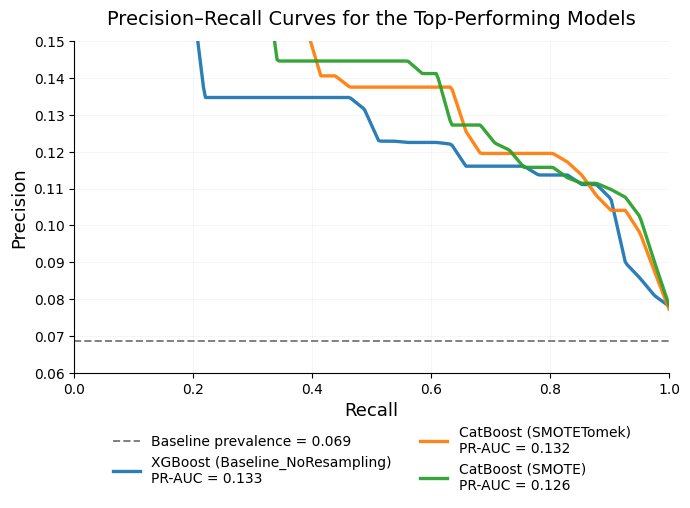

In [7]:
from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Precision–Recall Curves for Top-Performing Models
# ==========================================

top_n = 3

top_models_df = results_df.sort_values(
    ["PR-AUC", "ROC-AUC"],
    ascending=False
).head(top_n)

pr_curve_dir = FIGURE_DIR / "pr_curves"
pr_curve_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 6), facecolor="white")
ax.set_facecolor("white")

baseline_prevalence = y_test.mean()

ax.axhline(
    baseline_prevalence,
    linestyle="--",
    color="gray",
    linewidth=1.4,
    label=f"Baseline prevalence = {baseline_prevalence:.3f}"
)

recall_grid = np.linspace(0, 1, 300)

for _, row in top_models_df.iterrows():

    model_name  = row["Model"]
    method_name = row["Imbalance_Method"]
    pr_auc      = row["PR-AUC"]

    model_key = f"{model_name}__{method_name}"
    y_prob    = trained_models[model_key]["probabilities"]

    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    order     = np.argsort(recall)
    recall    = recall[order]
    precision = precision[order]

    uniq_recall    = np.unique(recall)
    uniq_precision = np.array([
        precision[recall == r].max() for r in uniq_recall
    ])

    precision_env    = np.maximum.accumulate(uniq_precision[::-1])[::-1]
    precision_smooth = np.interp(recall_grid, uniq_recall, precision_env)

    label = f"{model_name} ({method_name})\nPR-AUC = {pr_auc:.3f}"

    ax.plot(
        recall_grid,
        precision_smooth,
        linewidth=2.4,
        alpha=0.95,
        label=label
    )

ax.set_xlabel("Recall", fontsize=13)
ax.set_ylabel("Precision", fontsize=13)
ax.set_title("Precision–Recall Curves for the Top-Performing Models", fontsize=14, pad=12)

ax.set_xlim(0, 1)
ax.set_ylim(0.06, 0.15)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.grid(alpha=0.15, linewidth=0.6)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    frameon=False,
    fontsize=10,
    ncol=2
)

plt.tight_layout(rect=[0, 0.08, 1, 0.97])

plt.savefig(
    pr_curve_dir / "top_models_pr_curve_final.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [13]:
# Extract best XGBoost hyperparameters for downstream use
best_xgb_key = "XGBoost__Baseline_NoResampling"
best_xgb_pipeline = trained_models[best_xgb_key]["model"]
best_xgb_params = trained_models[best_xgb_key]["best_params"]

clean_params = {k.replace("model__", ""): v for k, v in best_xgb_params.items()}
print("clean_params:", clean_params)

clean_params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.005, 'colsample_bytree': 0.8}


### Feature Budget Optimization & SHAP XAI
ทำการหาจุดคุ้มทุนแบบพลวัต (Dynamic Cost-Effective Budget) และสร้างกราฟ SHAP ตามจำนวนตัวแปรที่เหมาะสมที่สุด

Booster features: 66
Cycle_Number in booster: True

Top 20 features by importance:
Uterine_Factors                    0.075656
Total_Female_Pathology             0.055389
Ovulatory_Factors                  0.045862
Cycle_Day                          0.039680
First_Count                        0.037691
Pre_Count                          0.036933
Post_TPMSC                         0.034115
Gynecological_Surgical_History     0.031796
Delta_Motile                       0.029400
Age_Female                         0.028938
First_Volume                       0.027768
Post_Count                         0.027762
Menstrual_Interval_Days            0.025447
First_Progressive_Motile           0.025427
First_TPMSC                        0.024925
BMI_InfertilityType_Interaction    0.024556
Ratio_TPMSC                        0.024235
Pre_Motile                         0.023030
Age_FSH_Interaction                0.022783
First_Motile                       0.021417
dtype: float32
X_train already has al

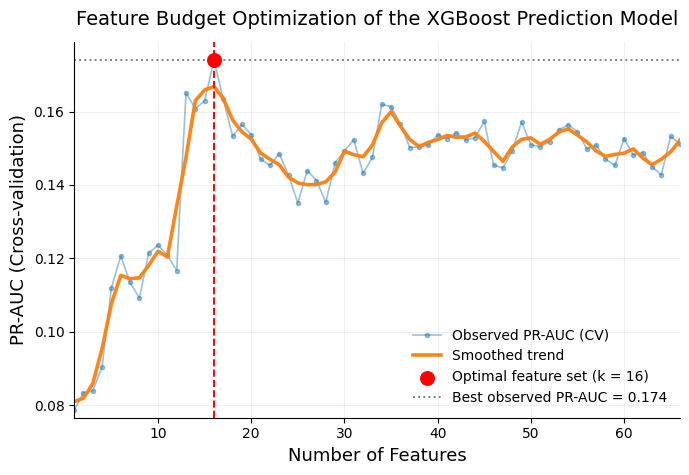

X_train_final shape: (2348, 16)
X_test_final shape:  (597, 16)


In [14]:
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.base import clone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Feature Budget Optimization (XGBoost + Baseline_NoResampling)

final_model_key = "XGBoost__Baseline_NoResampling"
xgb_model = trained_models[final_model_key]["model"]

booster = xgb_model.named_steps["model"] if hasattr(xgb_model, "named_steps") else xgb_model

# ✅ แก้แล้ว: ใช้ feature names จาก booster จริงๆ ไม่ใช่ X_train.columns
booster_feature_names = booster.get_booster().feature_names

feat_importance = pd.Series(
    booster.feature_importances_,
    index=booster_feature_names
).sort_values(ascending=False)

print(f"Booster features: {len(booster_feature_names)}")
print(f"Cycle_Number in booster: {'Cycle_Number' in booster_feature_names}")
print("\nTop 20 features by importance:")
print(feat_importance.head(20))

# Feature budget loop
group_cv_budget = GroupKFold(n_splits=3)
budget_results  = []

# ใช้ X_train ที่มี booster features ครบ
X_train_full = X_train.copy()

# ถ้า X_train ไม่มี Cycle_Number แต่ booster มี ต้องโหลดข้อมูลใหม่
missing_in_xtrain = [f for f in booster_feature_names if f not in X_train_full.columns]
if missing_in_xtrain:
    print(f"\n⚠️  Features in booster but missing in X_train: {missing_in_xtrain}")
    print("Loading full feature set from data...")

    import re
    from pathlib import Path
    from sklearn.impute import SimpleImputer
    from sklearn.model_selection import GroupShuffleSplit

    PROJECT_ROOT = Path.cwd().parent
    df_reload = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "cycle_level_features.csv")
    df_reload.columns = [re.sub(r"[\[\]<>]", "_", str(c)).replace(" ", "_") for c in df_reload.columns]
    df_reload = df_reload.loc[:, ~df_reload.columns.str.startswith('Unnamed')]
    if 'Date' in df_reload.columns:
        df_reload = df_reload.drop(columns=['Date'])
    df_reload['Result'] = pd.to_numeric(df_reload['Result'], errors='coerce')
    df_reload = df_reload.dropna(subset=['Result']).copy()
    df_reload['Result'] = df_reload['Result'].astype(int)
    df_reload['HN'] = df_reload['HN'].astype(str).str.strip()
    df_reload = df_reload[df_reload['HN'] != ""]

    groups_reload = df_reload['HN']
    gss_reload = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx_r, _ = next(gss_reload.split(df_reload, df_reload['Result'], groups=groups_reload))
    df_train_r = df_reload.iloc[train_idx_r].copy()

    exclude_base = ['HN', 'Result']
    feat_cols_r  = [c for c in df_train_r.columns if c not in exclude_base
                    and not c.startswith('Unnamed')]

    imp_r = SimpleImputer(strategy='median')
    X_train_full = pd.DataFrame(
        imp_r.fit_transform(df_train_r[feat_cols_r]),
        columns=feat_cols_r
    )
    y_train_budget      = df_train_r['Result'].values
    groups_train_budget = df_train_r['HN'].values
    print(f"Reloaded X_train shape: {X_train_full.shape}")
else:
    y_train_budget      = y_train
    groups_train_budget = groups_train
    print("X_train already has all booster features")

# ตรวจสอบ final
still_missing = [f for f in booster_feature_names if f not in X_train_full.columns]
if still_missing:
    raise ValueError(f"Still missing features: {still_missing}")

print(f"\nRunning feature budget loop (k=1 to {len(feat_importance)})...")

for k in range(1, len(feat_importance) + 1):
    top_k_features = feat_importance.index[:k].tolist()
    X_train_k      = X_train_full[top_k_features]
    model_k        = clone(booster)

    scores = cross_val_score(
        model_k,
        X_train_k,
        y_train_budget,
        groups=groups_train_budget,
        cv=group_cv_budget,
        scoring="average_precision",
        n_jobs=-1
    )

    budget_results.append({
        "Num_Features": k,
        "PR-AUC":       scores.mean(),
        "PR-AUC_std":   scores.std()
    })

    if k % 10 == 0 or k == 1:
        print(f"  k={k:3d}: PR-AUC = {scores.mean():.4f} ± {scores.std():.4f}")

budget_df_xgb = pd.DataFrame(budget_results)

max_score_xgb = budget_df_xgb["PR-AUC"].max()
max_idx       = budget_df_xgb["PR-AUC"].idxmax()
se_at_max     = budget_df_xgb.loc[max_idx, "PR-AUC_std"] / np.sqrt(3)
threshold_1se = max_score_xgb - se_at_max

optimal_k_xgb = budget_df_xgb.loc[
    budget_df_xgb["PR-AUC"] >= threshold_1se,
    "Num_Features"
].min()

print(f"\nMax PR-AUC: {max_score_xgb:.4f} at k={budget_df_xgb.loc[max_idx, 'Num_Features']}")
print(f"1-SE threshold: {threshold_1se:.4f}")
print(f"Optimal k (1-SE rule): {optimal_k_xgb}")
print(f"\nTop {optimal_k_xgb} selected features:")
for i, f in enumerate(feat_importance.index[:optimal_k_xgb].tolist(), 1):
    print(f"  {i:2d}. {f}")

budget_df_xgb.to_excel(REPORT_DIR / "feature_budget_xgb.xlsx", index=False)
print("\nFeature budget optimization complete")

# Plot
fig, ax = plt.subplots(figsize=(7, 5), facecolor="white")
ax.set_facecolor("white")

x = budget_df_xgb["Num_Features"]
y = budget_df_xgb["PR-AUC"]
y_smooth = y.rolling(window=3, center=True, min_periods=1).mean()

ax.plot(x, y, marker="o", markersize=3, lw=1.2, alpha=0.45, label="Observed PR-AUC (CV)")
ax.plot(x, y_smooth, lw=2.6, alpha=0.95, label="Smoothed trend")

opt_y = budget_df_xgb.loc[budget_df_xgb["Num_Features"] == optimal_k_xgb, "PR-AUC"].iloc[0]

ax.scatter(optimal_k_xgb, opt_y, s=95, color="red", zorder=6,
           label=f"Optimal feature set (k = {optimal_k_xgb})")
ax.axhline(y=max_score_xgb, linestyle=":", linewidth=1.4, color="gray",
           label=f"Best observed PR-AUC = {max_score_xgb:.3f}")
ax.axvline(x=optimal_k_xgb, linestyle="--", linewidth=1.4, color="red")

ax.set_xlabel("Number of Features", fontsize=13)
ax.set_ylabel("PR-AUC (Cross-validation)", fontsize=13)
ax.set_title("Feature Budget Optimization of the XGBoost Prediction Model", fontsize=14, pad=12)
ax.set_xlim(1, x.max())
ax.set_ylim(y.min() - 0.002, y.max() + 0.005)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.grid(alpha=0.18)
ax.legend(loc="lower right", frameon=False, fontsize=10)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(FIGURE_DIR / "feature_budget_xgb_final.png", dpi=300,
            bbox_inches="tight", facecolor="white")
plt.show()

# Define X_train_final and X_test_final for calibration cell
selected_features_xgb = feat_importance.index[:optimal_k_xgb].tolist()

imputer_final = SimpleImputer(strategy='median')
X_train_final = pd.DataFrame(
    imputer_final.fit_transform(X_train_full[selected_features_xgb]),
    columns=selected_features_xgb
)
X_test_final = pd.DataFrame(
    imputer_final.transform(X_test[selected_features_xgb]),
    columns=selected_features_xgb
)

# Save selected features for SHAP cell
pd.DataFrame({'Feature': selected_features_xgb}).to_excel(
    REPORT_DIR / "Final_Selected_Features_XGBoost_Baseline.xlsx", index=False
)

print(f"X_train_final shape: {X_train_final.shape}")
print(f"X_test_final shape:  {X_test_final.shape}")

HN overlap between subtrain and calibration set: 0
Subtrain size: 1643 | positives: 95 (5.8%)
Calibration size: 705 | positives: 47 (6.7%)
Full train event rate: 6.0%

Threshold derived from calibration set (Youden): 0.100962
NOTE: threshold fixed from cal set — test set evaluation is unbiased.

Brier before calibration: 0.2192
Brier after calibration:  0.0625
Improvement:              0.1567

Calibrated probability summary:
count    597.000000
mean       0.068867
std        0.044491
min        0.000000
25%        0.033898
50%        0.045802
75%        0.100962
max        0.502676
dtype: float64
Unique calibrated probs: 21


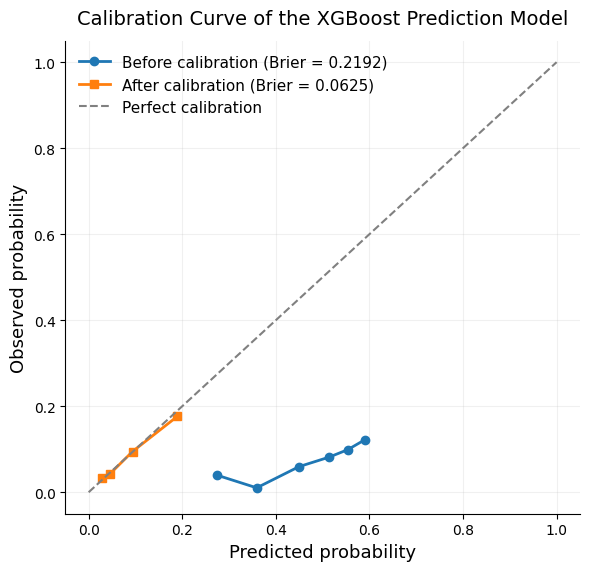


Calibration complete (isotonic, 30% cal set).


In [16]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, roc_curve
from sklearn.isotonic import IsotonicRegression
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib

required_objects = [
    "X_train_final",
    "X_test_final",
    "y_train",
    "y_test",
    "groups_train",
    "clean_params"
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise ValueError(f"{obj_name} not found. Please run the previous blocks first.")

# -----------------------------
# Align groups_train to X_train_final index
# FIX: ใช้ .values เพื่อ drop original index ก่อน assign ใหม่
# -----------------------------
groups_train_aligned = pd.Series(
    groups_train.values if isinstance(groups_train, pd.Series) else groups_train,
    index=X_train_final.index,
    name="HN"
)

if len(groups_train_aligned) != len(X_train_final):
    raise ValueError("groups_train length does not match X_train_final length.")

# -----------------------------
# Stratified group-aware calibration split — 30%
# -----------------------------
y_train_arr = y_train.values if isinstance(y_train, pd.Series) else np.array(y_train)
groups_arr  = groups_train_aligned.values

unique_patients = (pd.DataFrame({"HN": groups_arr, "y": y_train_arr})
                   .drop_duplicates("HN").set_index("HN")["y"])
pos_patients = unique_patients[unique_patients == 1].index.tolist()
neg_patients = unique_patients[unique_patients == 0].index.tolist()

rng = np.random.RandomState(42)
rng.shuffle(pos_patients)
rng.shuffle(neg_patients)

n_pos_cal = max(1, int(len(pos_patients) * 0.30))
n_neg_cal = max(1, int(len(neg_patients) * 0.30))
cal_patients = set(pos_patients[:n_pos_cal]) | set(neg_patients[:n_neg_cal])

cal_mask      = pd.Series(groups_arr).isin(cal_patients).values
subtrain_mask = ~cal_mask

subtrain_idx = np.where(subtrain_mask)[0]
cal_idx      = np.where(cal_mask)[0]

X_subtrain = X_train_final.iloc[subtrain_idx].copy()
y_subtrain = y_train.iloc[subtrain_idx].copy()
X_cal      = X_train_final.iloc[cal_idx].copy()
y_cal      = y_train.iloc[cal_idx].copy()

groups_subtrain = groups_train_aligned.iloc[subtrain_idx]
groups_cal      = groups_train_aligned.iloc[cal_idx]

# Sanity check
overlap = set(groups_subtrain).intersection(set(groups_cal))
print(f"HN overlap between subtrain and calibration set: {len(overlap)}")
assert len(overlap) == 0, "Patient leakage detected."

print(f"Subtrain size: {len(X_subtrain)} | positives: {int(y_subtrain.sum())} ({y_subtrain.mean():.1%})")
print(f"Calibration size: {len(X_cal)} | positives: {int(y_cal.sum())} ({y_cal.mean():.1%})")
print(f"Full train event rate: {y_train_arr.mean():.1%}")

# -----------------------------
# Fit base XGBoost on subtrain
# -----------------------------
pos_weight_subtrain = float(
    (len(y_subtrain) - y_subtrain.sum()) / max(y_subtrain.sum(), 1)
)

xgb_for_cal = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=pos_weight_subtrain,
    **clean_params
)
xgb_for_cal.fit(X_subtrain, y_subtrain)

# -----------------------------
# Isotonic regression calibration
# -----------------------------
cal_probs_raw = xgb_for_cal.predict_proba(X_cal)[:, 1]
iso_reg = IsotonicRegression(out_of_bounds="clip")
iso_reg.fit(cal_probs_raw, y_cal)

# -----------------------------
# Threshold จาก calibrated probs บน cal set
# -----------------------------
cal_probs_calibrated = np.clip(iso_reg.predict(cal_probs_raw), 0, 1)
fpr_cal, tpr_cal, thresholds_cal = roc_curve(y_cal, cal_probs_calibrated)
THRESHOLD = float(thresholds_cal[(tpr_cal - fpr_cal).argmax()])
print(f"\nThreshold derived from calibration set (Youden): {THRESHOLD:.6f}")
print("NOTE: threshold fixed from cal set — test set evaluation is unbiased.")

# -----------------------------
# Predict on test set
# -----------------------------
test_probs_raw        = xgb_for_cal.predict_proba(X_test_final)[:, 1]
test_probs_calibrated = np.clip(iso_reg.predict(test_probs_raw), 0, 1)

# -----------------------------
# Metrics
# -----------------------------
brier_before = brier_score_loss(y_test, test_probs_raw)
brier_after  = brier_score_loss(y_test, test_probs_calibrated)

print(f"\nBrier before calibration: {brier_before:.4f}")
print(f"Brier after calibration:  {brier_after:.4f}")
print(f"Improvement:              {brier_before - brier_after:.4f}")

print("\nCalibrated probability summary:")
print(pd.Series(test_probs_calibrated).describe())
print(f"Unique calibrated probs: {len(np.unique(test_probs_calibrated))}")

# -----------------------------
# Save probability table + threshold
# -----------------------------
calibration_pred_df = pd.DataFrame({
    "y_true":          y_test,
    "prob_raw":        test_probs_raw,
    "prob_calibrated": test_probs_calibrated
})
calibration_pred_df.to_excel(
    REPORT_DIR / "Calibration_Test_Probabilities_Final_XGBoost_Baseline.xlsx",
    index=False
)

pd.DataFrame([{"threshold": THRESHOLD, "source": "calibration_set_youden_isotonic_30pct"}]).to_excel(
    REPORT_DIR / "calibration_threshold.xlsx", index=False
)

# -----------------------------
# Save model objects
# -----------------------------
final_model_dir = MODEL_DIR / "final_model"
final_model_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(xgb_for_cal, final_model_dir / "XGBoost_Baseline_calibration_base_model.joblib")
joblib.dump(iso_reg,     final_model_dir / "isotonic_calibrator_final_xgb.joblib")

# -----------------------------
# Calibration curves
# -----------------------------
prob_true_before, prob_pred_before = calibration_curve(
    y_test, test_probs_raw, n_bins=6, strategy="quantile"
)
prob_true_after, prob_pred_after = calibration_curve(
    y_test, test_probs_calibrated, n_bins=6, strategy="quantile"
)

fig, ax = plt.subplots(figsize=(6, 6), facecolor="white")
ax.set_facecolor("white")
ax.plot(prob_pred_before, prob_true_before, marker="o", linewidth=2,
        label=f"Before calibration (Brier = {brier_before:.4f})")
ax.plot(prob_pred_after,  prob_true_after,  marker="s", linewidth=2,
        label=f"After calibration (Brier = {brier_after:.4f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.set_xlabel("Predicted probability", fontsize=13)
ax.set_ylabel("Observed probability", fontsize=13)
ax.set_title("Calibration Curve of the XGBoost Prediction Model", fontsize=14, pad=12)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.grid(alpha=0.18)
ax.legend(frameon=False, fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(FIGURE_DIR / "Calibration_Plot_Final_XGBoost_Baseline.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.close()

print("\nCalibration complete (isotonic, 30% cal set).")

In [17]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, confusion_matrix, accuracy_score, f1_score,
)
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.impute import SimpleImputer
import joblib
import re

PROJECT_ROOT = Path.cwd().parent
REPORT_DIR   = PROJECT_ROOT / "reports" / "tables"
MODEL_DIR    = PROJECT_ROOT / "models" / "saved_models"

# ==========================================
# โหลด 16-feature model probabilities + threshold
# ==========================================
cal_df_16   = pd.read_excel(REPORT_DIR / "Calibration_Test_Probabilities_Final_XGBoost_Baseline.xlsx")
y_true      = cal_df_16['y_true'].values
prob_raw_16 = cal_df_16['prob_raw'].values
prob_cal_16 = cal_df_16['prob_calibrated'].values

# FIX: โหลด threshold จาก calibration set ไม่ recompute บน test set
threshold_df = pd.read_excel(REPORT_DIR / "calibration_threshold.xlsx")
THRESHOLD_16 = float(threshold_df["threshold"].iloc[0])
print(f"16-feature model threshold (from cal set): {THRESHOLD_16:.6f}")

# ==========================================
# โหลด full 66-feature model แล้ว calibrate
# ==========================================
df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "cycle_level_features.csv")
df.columns = [re.sub(r"[\[\]<>]", "_", str(c)).replace(" ", "_") for c in df.columns]
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
if 'Date' in df.columns:
    df = df.drop(columns=['Date'])
df['Result'] = pd.to_numeric(df['Result'], errors='coerce')
df = df.dropna(subset=['Result'])
df['Result'] = df['Result'].astype(int)
df['HN'] = df['HN'].astype(str).str.strip()
df = df[df['HN'] != ""]

groups = df['HN']
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, df['Result'], groups=groups))
df_train = df.iloc[train_idx].copy()
df_test  = df.iloc[test_idx].copy()
y_train_arr = df_train['Result'].values
groups_arr  = df_train['HN'].values

exclude_base = ['HN', 'Result']
feat_cols_66 = [c for c in df.columns if c not in exclude_base
                and not c.startswith('Unnamed')]

imputer    = SimpleImputer(strategy='median')
X_train_66 = pd.DataFrame(imputer.fit_transform(df_train[feat_cols_66]), columns=feat_cols_66)
X_test_66  = pd.DataFrame(imputer.transform(df_test[feat_cols_66]),      columns=feat_cols_66)

full_model    = joblib.load(MODEL_DIR / "XGBoost" / "XGBoost_Baseline_NoResampling.joblib")
prob_raw_full = full_model.predict_proba(X_test_66)[:, 1]

# FIX: Stratified group-aware calibration split เหมือน cell 15
unique_patients = (pd.DataFrame({"HN": groups_arr, "y": y_train_arr})
                   .drop_duplicates("HN").set_index("HN")["y"])
pos_patients = unique_patients[unique_patients == 1].index.tolist()
neg_patients = unique_patients[unique_patients == 0].index.tolist()

rng = np.random.RandomState(42)
rng.shuffle(pos_patients)
rng.shuffle(neg_patients)

cal_patients  = (set(pos_patients[:max(1, int(len(pos_patients) * 0.20))]) |
                 set(neg_patients[:max(1, int(len(neg_patients) * 0.20))]))
cal_mask_full = pd.Series(groups_arr).isin(cal_patients).values

X_cal_full = X_train_66.iloc[np.where(cal_mask_full)[0]]
y_cal_full = pd.Series(y_train_arr).iloc[np.where(cal_mask_full)[0]]

cal_probs_full = full_model.predict_proba(X_cal_full)[:, 1]
iso_full = IsotonicRegression(out_of_bounds='clip')
iso_full.fit(cal_probs_full, y_cal_full)
prob_cal_full = np.clip(iso_full.predict(prob_raw_full), 0, 1)

# FIX: threshold full model จาก cal set Youden ด้วย
cal_probs_full_calibrated = np.clip(iso_full.predict(cal_probs_full), 0, 1)
fpr_f, tpr_f, th_f = roc_curve(y_cal_full, cal_probs_full_calibrated)
THRESHOLD_FULL = float(th_f[(tpr_f - fpr_f).argmax()])
print(f"Full model threshold (from cal set):       {THRESHOLD_FULL:.6f}")
print(f"\nFull model unique cal probs: {len(np.unique(prob_cal_full))}")
print(f"16-feat unique cal probs:    {len(np.unique(prob_cal_16))}")

# ==========================================
# Report function — threshold รับเข้ามาจากภายนอก
# ==========================================
def report_metrics(y_true, prob_raw, prob_cal, threshold, model_name):
    roc = roc_auc_score(y_true, prob_raw)
    pr  = average_precision_score(y_true, prob_raw)

    y_pred          = (prob_cal >= threshold).astype(int)
    tn, fp, fn, tp  = confusion_matrix(y_true, y_pred).ravel()

    sens      = tp / (tp + fn)
    spec      = tn / (tn + fp)
    npv       = tn / (tn + fn)
    ppv       = tp / (tp + fp) if (tp + fp) > 0 else 0
    acc       = accuracy_score(y_true, y_pred)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    brier_raw = brier_score_loss(y_true, prob_raw)
    brier_cal = brier_score_loss(y_true, prob_cal)

    print(f"\n{'='*62}")
    print(f"  {model_name}")
    print(f"{'='*62}")
    print(f"{'Metric':<28} {'Value':>10}  Source")
    print(f"{'-'*55}")
    print(f"{'ROC-AUC':<28} {roc:>10.4f}  raw")
    print(f"{'PR-AUC (Avg Precision)':<28} {pr:>10.4f}  raw")
    print(f"{'Brier (raw)':<28} {brier_raw:>10.4f}  raw")
    print(f"{'Brier (calibrated)':<28} {brier_cal:>10.4f}  calibrated ✅")
    print(f"{'-'*55}")
    print(f"{'Threshold':<28} {threshold:>10.4f}  Youden, cal set ✅")
    print(f"{'Sensitivity = Recall':<28} {sens:>10.4f}  ({sens*100:.1f}%)  calibrated")
    print(f"{'Specificity':<28} {spec:>10.4f}  ({spec*100:.1f}%)  calibrated")
    print(f"{'NPV':<28} {npv:>10.4f}  ({npv*100:.1f}%)  calibrated")
    print(f"{'PPV = Precision':<28} {ppv:>10.4f}  ({ppv*100:.1f}%)  calibrated")
    print(f"{'Accuracy':<28} {acc:>10.4f}  ({acc*100:.1f}%)  calibrated")
    print(f"{'F1 Score':<28} {f1:>10.4f}  calibrated")
    print(f"{'TP/FP/TN/FN':<28} {tp}/{fp}/{tn}/{fn}")

    return {
        'Model': model_name, 'ROC_AUC': round(roc, 4), 'PR_AUC': round(pr, 4),
        'Brier_raw': round(brier_raw, 4), 'Brier_cal': round(brier_cal, 4),
        'Threshold': round(threshold, 4),
        'Sensitivity': round(sens, 4), 'Specificity': round(spec, 4),
        'NPV': round(npv, 4), 'PPV': round(ppv, 4),
        'Accuracy': round(acc, 4), 'F1': round(f1, 4),
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn
    }

# ==========================================
# Report ทั้งสอง model
# ==========================================
r_full = report_metrics(y_true, prob_raw_full, prob_cal_full, THRESHOLD_FULL, "Full Model (66 features)")
r_16   = report_metrics(y_true, prob_raw_16,   prob_cal_16,   THRESHOLD_16,   "Final Model (16 features, postwash)")

comp = pd.DataFrame([r_full, r_16])
comp.to_excel(REPORT_DIR / "Full_vs_16feature_metrics.xlsx", index=False)

print(f"\n\n{'='*62}")
print("  Comparison Table")
print(f"{'='*62}")
print(comp[[
    'Model', 'ROC_AUC', 'PR_AUC', 'Brier_cal',
    'Sensitivity', 'Specificity', 'NPV', 'PPV', 'Accuracy', 'F1'
]].to_string(index=False))
print(f"\nSaved: Full_vs_16feature_metrics.xlsx ✅")

16-feature model threshold (from cal set): 0.100962
Full model threshold (from cal set):       0.105263

Full model unique cal probs: 17
16-feat unique cal probs:    21

  Full Model (66 features)
Metric                            Value  Source
-------------------------------------------------------
ROC-AUC                          0.6989  raw
PR-AUC (Avg Precision)           0.1335  raw
Brier (raw)                      0.2141  raw
Brier (calibrated)               0.0748  calibrated ✅
-------------------------------------------------------
Threshold                        0.1053  Youden, cal set ✅
Sensitivity = Recall             0.6341  (63.4%)  calibrated
Specificity                      0.6493  (64.9%)  calibrated
NPV                              0.9601  (96.0%)  calibrated
PPV = Precision                  0.1176  (11.8%)  calibrated
Accuracy                         0.6482  (64.8%)  calibrated
F1 Score                         0.1985  calibrated
TP/FP/TN/FN                  26/195/36

X_train_16 shape: (2348, 16)
X_test_final shape: (597, 16)

SHAP model trained on full train set (2348 rows, 16 features)

Computing SHAP values...
SHAP values shape: (597, 16)

SHAP Feature Importance:
 Rank                         Feature_Display  Mean_Abs_SHAP
    1                          Uterine factor       0.251002
    2            Total female pathology score       0.081665
    3           Menstrual cycle length (days)       0.049381
    4                Postwash TPMSC (million)       0.048078
    5   Prewash sperm concentration (×10⁶/mL)       0.035840
    6 Change in total motility after wash (%)       0.031096
    7   Initial sperm concentration (×10⁶/mL)       0.030241
    8                      Female age (years)       0.026263
    9                        Ovulatory factor       0.023528
   10                 Initial TPMSC (million)       0.015019
   11                           IUI cycle day       0.013928
   12        Initial progressive motility (%)       0.013866
   1

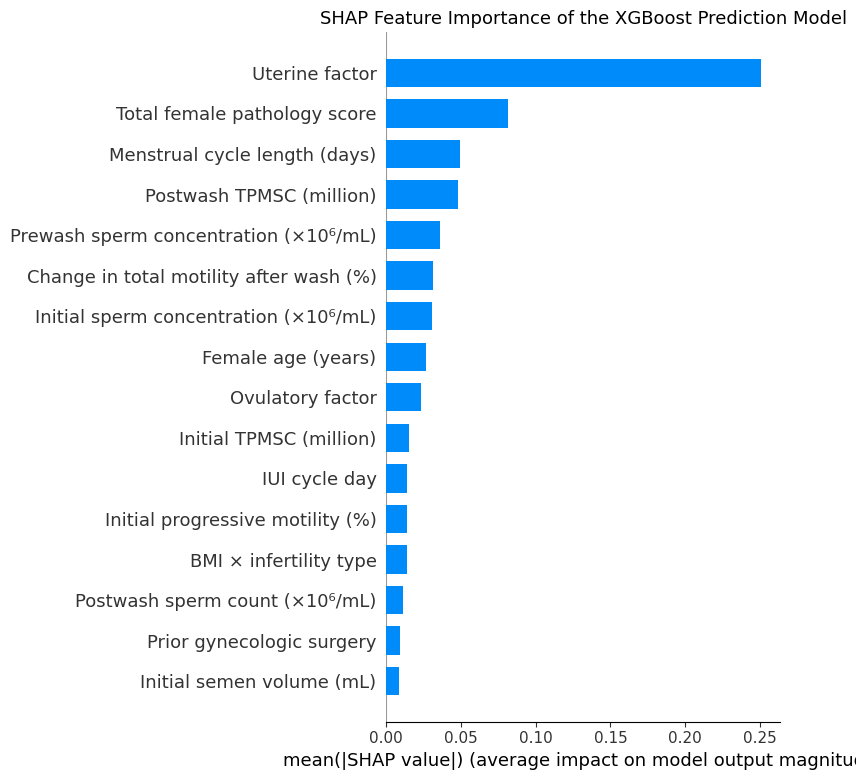

Saved: SHAP_Bar_Final_XGBoost_Baseline.png


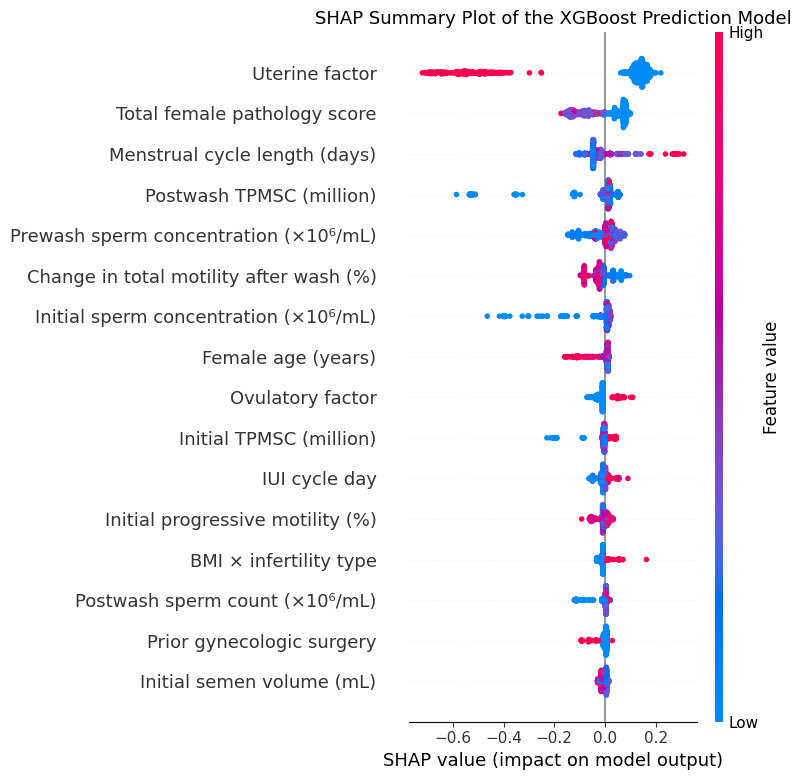

Saved: SHAP_Beeswarm_Final_XGBoost_Baseline.png

✅ SHAP analysis complete


In [18]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier

PROJECT_ROOT = Path.cwd().parent
REPORT_DIR   = PROJECT_ROOT / "reports" / "tables"
MODEL_DIR    = PROJECT_ROOT / "models" / "saved_models"
FIGURE_DIR   = PROJECT_ROOT / "reports" / "figures"

# ==========================================
# โหลด selected features
# ==========================================
selected_features_xgb = pd.read_excel(
    REPORT_DIR / "Final_Selected_Features_XGBoost_Baseline.xlsx"
)['Feature'].tolist()

# ==========================================
# โหลด data + split (same seed)
# ==========================================
df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "cycle_level_features.csv")
df.columns = [re.sub(r"[\[\]<>]", "_", str(c)).replace(" ", "_") for c in df.columns]
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
if 'Date' in df.columns:
    df = df.drop(columns=['Date'])
df['Result'] = pd.to_numeric(df['Result'], errors='coerce')
df = df.dropna(subset=['Result'])
df['Result'] = df['Result'].astype(int)
df['HN'] = df['HN'].astype(str).str.strip()
df = df[df['HN'] != ""]

groups = df['HN']
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, df['Result'], groups=groups))
df_train = df.iloc[train_idx].copy()
df_test  = df.iloc[test_idx].copy()

# ==========================================
# Prepare X_train และ X_test บน 16 features
# ==========================================
imputer = SimpleImputer(strategy='median')
X_train_16 = pd.DataFrame(
    imputer.fit_transform(df_train[selected_features_xgb]),
    columns=selected_features_xgb
)
X_test_final = pd.DataFrame(
    imputer.transform(df_test[selected_features_xgb]),
    columns=selected_features_xgb
)
y_train_16 = df_train['Result'].values

print(f"X_train_16 shape: {X_train_16.shape}")
print(f"X_test_final shape: {X_test_final.shape}")

# ==========================================
# Train XGBoost บน full train set, 16 features
# ใช้ clean_params เดิมจาก feature budget
# ==========================================
pos_weight_full = float((len(y_train_16) - y_train_16.sum()) / max(y_train_16.sum(), 1))

shap_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=pos_weight_full,
    **clean_params
)
shap_model.fit(X_train_16, y_train_16)
print(f"\nSHAP model trained on full train set ({len(X_train_16)} rows, 16 features)")

# ==========================================
# Feature display name mapping
# ==========================================
feature_name_map = {
    'Age_Female':                     'Female age (years)',
    'Total_Female_Pathology':         'Total female pathology score',
    'Ovulatory_Factors':              'Ovulatory factor',
    'Cycle_Day':                      'IUI cycle day',
    'First_Count':                    'Initial sperm concentration (×10⁶/mL)',
    'Pre_Count':                      'Prewash sperm concentration (×10⁶/mL)',
    'Post_TPMSC':                     'Postwash TPMSC (million)',
    'Gynecological_Surgical_History': 'Prior gynecologic surgery',
    'Delta_Motile':                   'Change in total motility after wash (%)',
    'Uterine_Factors':                'Uterine factor',
    'First_Volume':                   'Initial semen volume (mL)',
    'Post_Count':                     'Postwash sperm count (×10⁶/mL)',
    'Menstrual_Interval_Days':        'Menstrual cycle length (days)',
    'First_Progressive_Motile':       'Initial progressive motility (%)',
    'First_TPMSC':                    'Initial TPMSC (million)',
    'BMI_InfertilityType_Interaction':'BMI × infertility type',
}

display_names              = [feature_name_map.get(f, f) for f in selected_features_xgb]
X_test_final_named         = X_test_final.copy()
X_test_final_named.columns = display_names

# ==========================================
# SHAP analysis
# ==========================================
print("\nComputing SHAP values...")
explainer   = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_test_final)

if isinstance(shap_values, list):
    shap_values = shap_values[1]
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
if not isinstance(shap_values, np.ndarray):
    raise ValueError("Unexpected SHAP output format.")
if shap_values.shape[1] != X_test_final.shape[1]:
    raise ValueError(f"SHAP shape mismatch: {shap_values.shape[1]} vs {X_test_final.shape[1]}")

print(f"SHAP values shape: {shap_values.shape}")

# SHAP importance table
feat_imp_df = pd.DataFrame({
    "Feature":         selected_features_xgb,
    "Feature_Display": display_names,
    "Mean_Abs_SHAP":   np.abs(shap_values).mean(axis=0)
}).sort_values("Mean_Abs_SHAP", ascending=False).reset_index(drop=True)
feat_imp_df['Rank'] = range(1, len(feat_imp_df) + 1)

print("\nSHAP Feature Importance:")
print(feat_imp_df[['Rank', 'Feature_Display', 'Mean_Abs_SHAP']].to_string(index=False))
feat_imp_df.to_excel(
    REPORT_DIR / "SHAP_Feature_Importance_Final_XGBoost_Baseline.xlsx",
    index=False
)

# ==========================================
# SHAP Bar Plot
# ==========================================
shap_dir = FIGURE_DIR / "shap_final_xgb"
shap_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(9, 6), facecolor='white')
shap.summary_plot(
    shap_values, X_test_final_named,
    plot_type="bar",
    max_display=len(selected_features_xgb),
    show=False
)
plt.title("SHAP Feature Importance of the XGBoost Prediction Model", fontsize=13)
plt.tight_layout()
plt.savefig(shap_dir / "SHAP_Bar_Final_XGBoost_Baseline.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()
print("Saved: SHAP_Bar_Final_XGBoost_Baseline.png")

# ==========================================
# SHAP Beeswarm Plot
# ==========================================
plt.figure(figsize=(10, 7), facecolor='white')
shap.summary_plot(
    shap_values, X_test_final_named,
    max_display=len(selected_features_xgb),
    show=False
)
plt.title("SHAP Summary Plot of the XGBoost Prediction Model", fontsize=13)
plt.tight_layout()
plt.savefig(shap_dir / "SHAP_Beeswarm_Final_XGBoost_Baseline.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()
print("Saved: SHAP_Beeswarm_Final_XGBoost_Baseline.png")

print("\n✅ SHAP analysis complete")

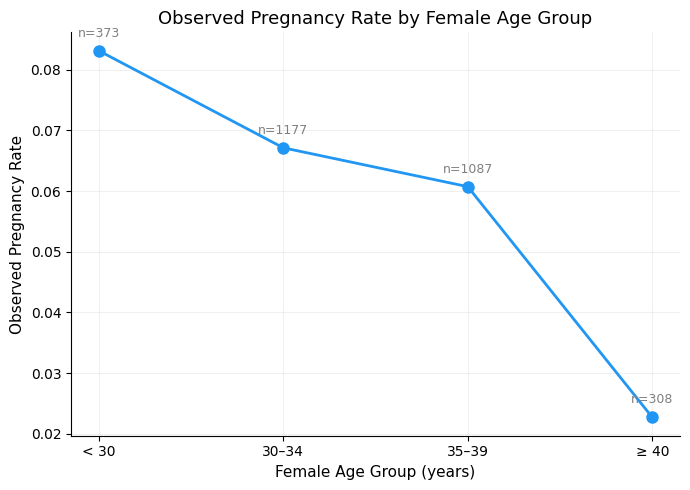

Age line summary:
   Age_Group  Pregnancy_Rate  Count
0      < 30        0.083110    373
1     30–34        0.067120   1177
2     35–39        0.060718   1087
3      ≥ 40        0.022727    308


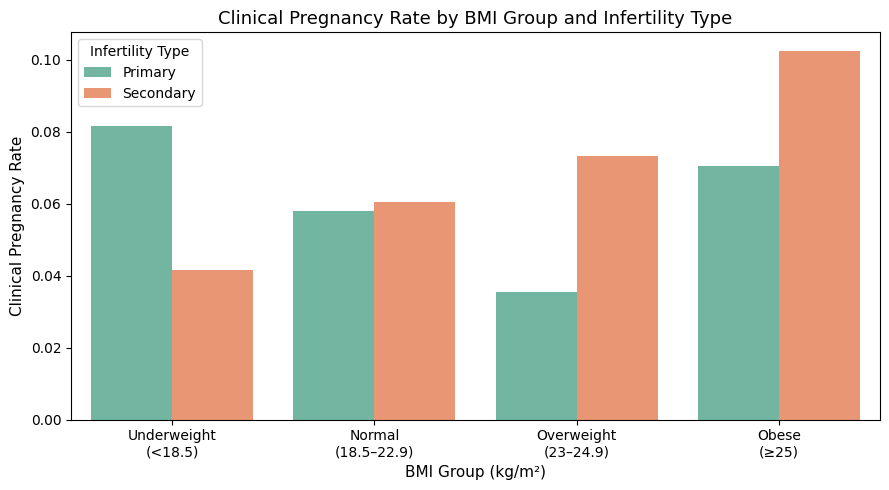

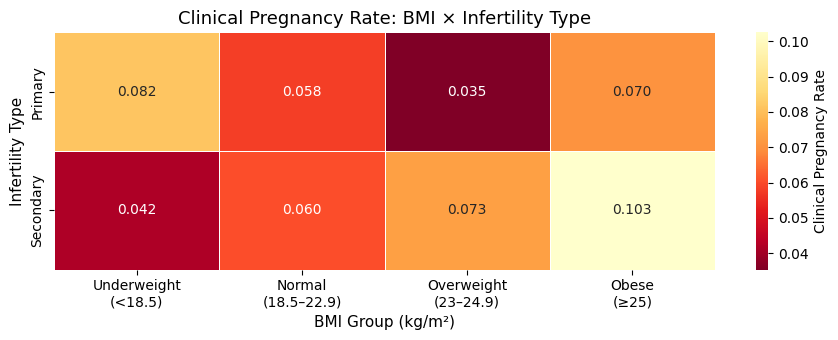


BMI × Infertility summary:
             BMI_Group Infertility_Label  Pregnancy_Rate  Count
 Underweight\n(<18.5)           Primary        0.081545    233
 Underweight\n(<18.5)         Secondary        0.041667     48
  Normal\n(18.5–22.9)           Primary        0.058081   1188
  Normal\n(18.5–22.9)         Secondary        0.060440    364
Overweight\n(23–24.9)           Primary        0.035354    396
Overweight\n(23–24.9)         Secondary        0.073394    109
         Obese\n(≥25)           Primary        0.070388    412
         Obese\n(≥25)         Secondary        0.102564    195


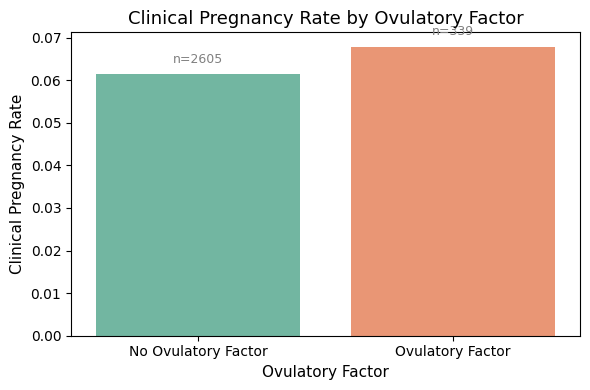

Ovulatory factor summary:
                          mean  count
Ovulatory_Label                     
No Ovulatory Factor  0.061420   2605
Ovulatory Factor     0.067847    339


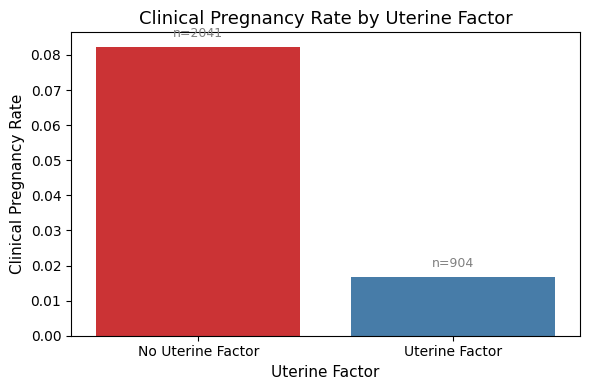

Uterine factor summary:
                        mean  count
Uterine_Label                     
No Uterine Factor  0.082313   2041
Uterine Factor     0.016593    904


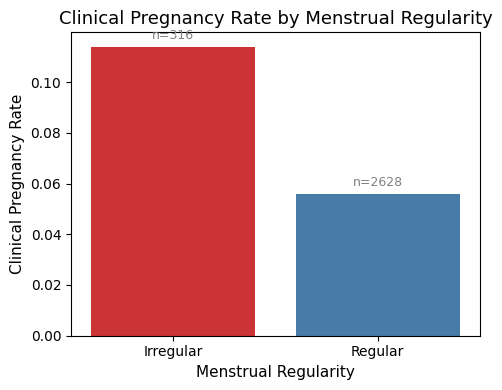

Menstrual regularity summary:
                      mean  count
Menstrual_Label                 
Irregular        0.113924    316
Regular          0.055936   2628


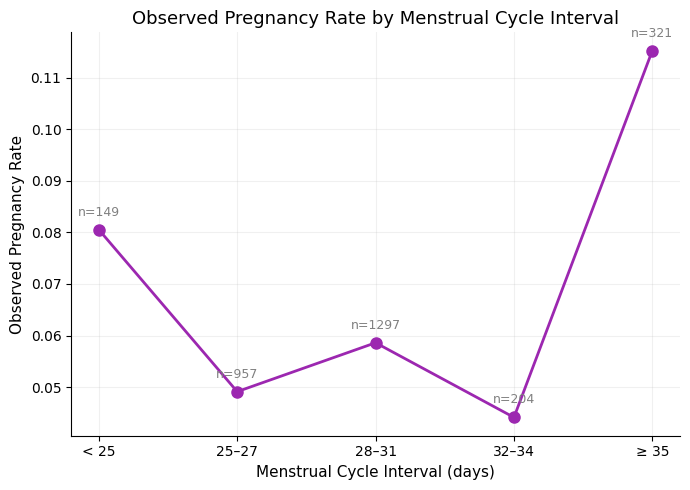

Menstrual interval summary:
   Interval_Group  Pregnancy_Rate  Count
0           < 25        0.080537    149
1          25–27        0.049112    957
2          28–31        0.058597   1297
3          32–34        0.044118    204
4           ≥ 35        0.115265    321


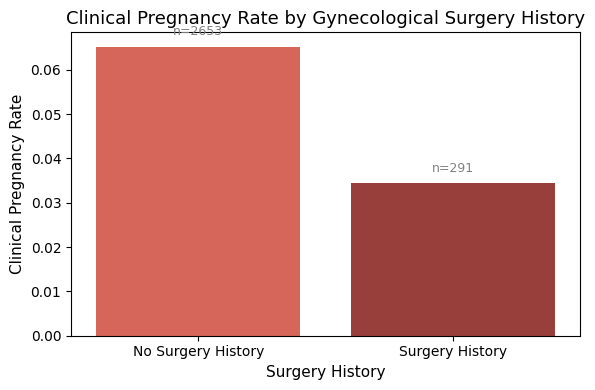

Surgical history summary:
                         mean  count
Surgery_Label                      
No Surgery History  0.065209   2653
Surgery History     0.034364    291


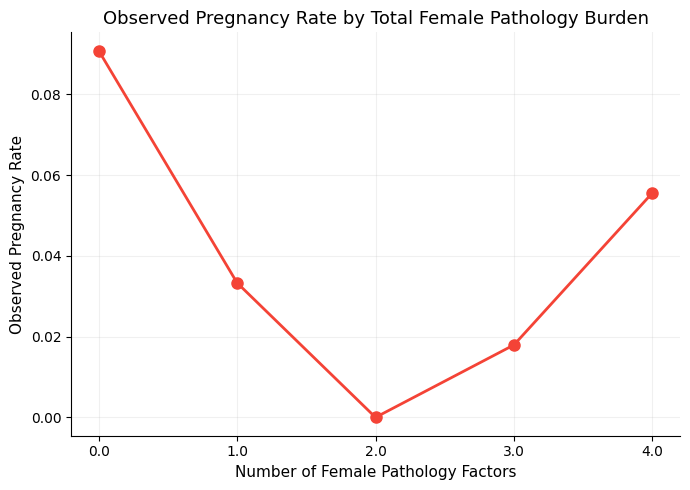

Total pathology summary:
    Pathology_Score  Pregnancy_Rate  Count
0              0.0        0.090791   1542
1              1.0        0.033304   1141
2              2.0        0.000000     21
3              3.0        0.017937    223
4              4.0        0.055556     18


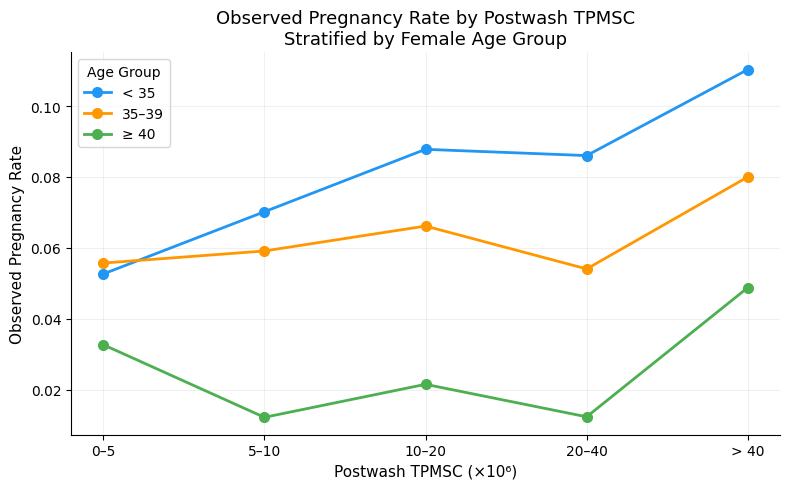

TPMSC × Age summary:
 TPMSC_Bin Age_Group  Pregnancy_Rate  Count
      0–5      < 35        0.052632    380
      0–5     35–39        0.055703    377
      0–5      ≥ 40        0.032680    153
     5–10      < 35        0.070175    228
     5–10     35–39        0.059113    203
     5–10      ≥ 40        0.012195     82
    10–20      < 35        0.087786    262
    10–20     35–39        0.066148    257
    10–20      ≥ 40        0.021505     93
    20–40      < 35        0.086022    279
    20–40     35–39        0.054054    222
    20–40      ≥ 40        0.012346     81
     > 40      < 35        0.110294    136
     > 40     35–39        0.080000    150
     > 40      ≥ 40        0.048780     41


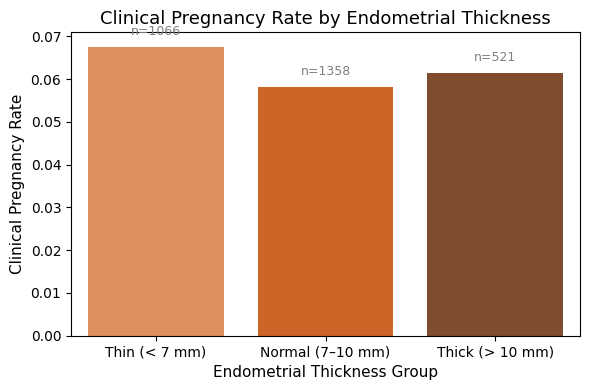

Endometrium summary:
                       mean  count
Endo_Group                       
Thin (< 7 mm)     0.067542   1066
Normal (7–10 mm)  0.058174   1358
Thick (> 10 mm)   0.061420    521


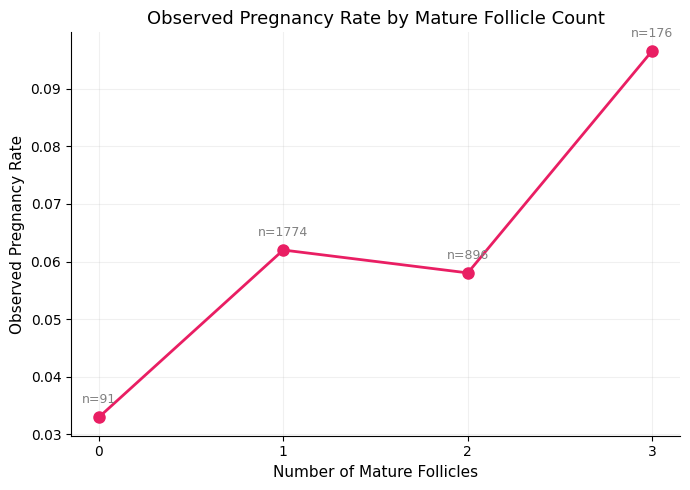

Follicle count summary:
    Follicle_Count  Pregnancy_Rate  Count
0               0        0.032967     91
1               1        0.062007   1774
2               2        0.058036    896
3               3        0.096591    176


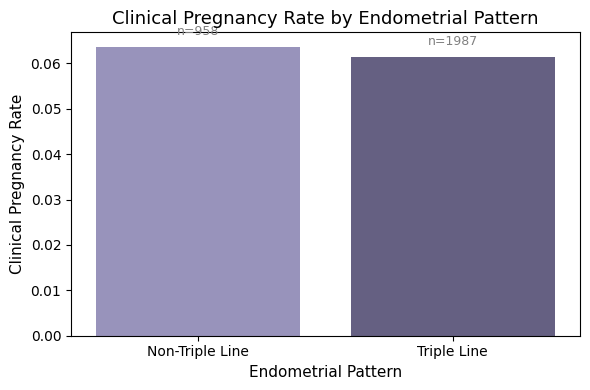

Triple line endo summary:
                      mean  count
Endo_Label                      
Non-Triple Line  0.063674    958
Triple Line      0.061399   1987


,mean,count
Endo_Label,,
Non-Triple Line,0.063674,958
Triple Line,0.061399,1987


In [27]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ======================
# Setup
# ======================
plt.close('all')
plt.rcParams.update(plt.rcParamsDefault)

os.makedirs('reports_q1/figures/shap', exist_ok=True)
os.makedirs('reports_q1/figures/clinical', exist_ok=True)

TARGET = 'Result'

plot_df = df.copy()
plot_df = plot_df.dropna(subset=[TARGET])
plot_df[TARGET] = pd.to_numeric(plot_df[TARGET], errors='coerce')
plot_df = plot_df.dropna(subset=[TARGET])

# ======================
# HELPER
# ======================
def add_n_labels(ax, means, counts):
    for i, (v, c) in enumerate(zip(means, counts)):
        ax.text(i, v + 0.002, f'n={c}',
                ha='center', va='bottom', fontsize=9, color='gray')


def line_plot(ax, x_vals, y_vals, color='#2196F3', marker='o'):
    ax.plot(x_vals, y_vals, marker=marker, linewidth=2,
            markersize=8, color=color)


# ======================
# FEMALE FACTORS
# ======================

def plot_age_line(df):
    """Age group → pregnancy rate (line, เห็นจุดหัก)"""
    df = df.copy()
    df = df.dropna(subset=['Age_Female', TARGET])
    bins   = [0, 30, 35, 40, 100]
    labels = ['< 30', '30–34', '35–39', '≥ 40']
    df['Age_Group'] = pd.cut(df['Age_Female'], bins=bins, labels=labels)
    summary = df.groupby('Age_Group', observed=True)[TARGET].agg(['mean', 'count']).reset_index()
    summary.columns = ['Age_Group', 'Pregnancy_Rate', 'Count']

    plt.close('all')
    fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
    ax.set_facecolor('white')
    line_plot(ax, summary['Age_Group'], summary['Pregnancy_Rate'])
    for _, row in summary.iterrows():
        ax.annotate(f"n={int(row['Count'])}",
                    xy=(row['Age_Group'], row['Pregnancy_Rate']),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', fontsize=9, color='gray')
    ax.set_title("Observed Pregnancy Rate by Female Age Group", fontsize=13)
    ax.set_xlabel("Female Age Group (years)", fontsize=11)
    ax.set_ylabel("Observed Pregnancy Rate", fontsize=11)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.grid(alpha=0.18)
    plt.tight_layout()
    plt.savefig('reports_q1/figures/clinical/age_line.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("Age line summary:\n", summary)
    return summary


def plot_bmi_infertility(df):
    """BMI × Infertility type → bar + heatmap"""
    bmi_col  = next((c for c in df.columns if 'bmi' in c.lower() or 'body_mass' in c.lower()), None)
    type_col = next((c for c in df.columns if 'infertility_type' in c.lower()), None)
    if bmi_col is None or type_col is None:
        print(f"⚠️ Column not found — BMI: {bmi_col}, Type: {type_col}")
        return
    df = df.copy()

    # อ้างอิง: WHO Asia-Pacific / WPRO cutoffs สำหรับคนไทย
    # Overweight ≥23, Obese ≥25 (ไม่ใช่เกณฑ์ฝรั่งที่ตัดที่ 27.5)
    # Source: https://pmc.ncbi.nlm.nih.gov/articles/PMC5824639/
    #         https://pubmed.ncbi.nlm.nih.gov/14726171/
    bmi_bins   = [0, 18.5, 23, 25, 100]
    bmi_labels = ['Underweight\n(<18.5)', 'Normal\n(18.5–22.9)',
                  'Overweight\n(23–24.9)', 'Obese\n(≥25)']

    df['BMI_Group']         = pd.cut(df[bmi_col], bins=bmi_bins, labels=bmi_labels)
    df['Infertility_Label'] = df[type_col].map({0: 'Primary', 1: 'Secondary'})
    df = df.dropna(subset=['BMI_Group', 'Infertility_Label', TARGET])

    summary = df.groupby(['BMI_Group', 'Infertility_Label'], observed=True)[TARGET]\
                .agg(['mean', 'count']).reset_index()
    summary.columns = ['BMI_Group', 'Infertility_Label', 'Pregnancy_Rate', 'Count']

    plt.close('all')
    plt.figure(figsize=(9, 5))
    sns.barplot(data=summary, x='BMI_Group', y='Pregnancy_Rate',
                hue='Infertility_Label', palette='Set2')
    plt.title("Clinical Pregnancy Rate by BMI Group and Infertility Type", fontsize=13)
    plt.xlabel("BMI Group (kg/m²)", fontsize=11)
    plt.ylabel("Clinical Pregnancy Rate", fontsize=11)
    plt.legend(title="Infertility Type", fontsize=10)
    plt.tight_layout()
    plt.savefig('reports_q1/figures/clinical/bmi_infertility_bar.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    pivot = df.pivot_table(values=TARGET, index='Infertility_Label',
                           columns='BMI_Group', aggfunc='mean', observed=True)
    plt.close('all')
    plt.figure(figsize=(9, 3.5))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd_r', linewidths=0.5,
                cbar_kws={'label': 'Clinical Pregnancy Rate'})
    plt.title("Clinical Pregnancy Rate: BMI × Infertility Type", fontsize=13)
    plt.xlabel("BMI Group (kg/m²)", fontsize=11)
    plt.ylabel("Infertility Type", fontsize=11)
    plt.tight_layout()
    plt.savefig('reports_q1/figures/clinical/bmi_infertility_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("\nBMI × Infertility summary:\n", summary.to_string(index=False))
    return summary


def plot_ovulatory_factor(df):
    """Ovulatory factor (0/1) → bar"""
    if 'Ovulatory_Factors' not in df.columns:
        print("⚠️ Ovulatory_Factors not found")
        return
    df = df.copy()
    df['Ovulatory_Label'] = df['Ovulatory_Factors'].map({0: 'No Ovulatory Factor', 1: 'Ovulatory Factor'})
    df = df.dropna(subset=['Ovulatory_Label', TARGET])
    summary = df.groupby('Ovulatory_Label', observed=True)[TARGET].agg(['mean', 'count'])

    plt.close('all')
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.barplot(x=summary.index, y=summary['mean'], palette='Set2', ax=ax)
    add_n_labels(ax, summary['mean'], summary['count'])
    ax.set_title("Clinical Pregnancy Rate by Ovulatory Factor", fontsize=13)
    ax.set_xlabel("Ovulatory Factor", fontsize=11)
    ax.set_ylabel("Clinical Pregnancy Rate", fontsize=11)
    plt.tight_layout()
    plt.savefig('reports_q1/figures/clinical/ovulatory_factor.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("Ovulatory factor summary:\n", summary)
    return summary


def plot_uterine_factor(df):
    """Uterine factor (0/1) → bar"""
    if 'Uterine_Factors' not in df.columns:
        print("⚠️ Uterine_Factors not found")
        return
    df = df.copy()
    df['Uterine_Label'] = df['Uterine_Factors'].map({0: 'No Uterine Factor', 1: 'Uterine Factor'})
    df = df.dropna(subset=['Uterine_Label', TARGET])
    summary = df.groupby('Uterine_Label', observed=True)[TARGET].agg(['mean', 'count'])

    plt.close('all')
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.barplot(x=summary.index, y=summary['mean'], palette='Set1', ax=ax)
    add_n_labels(ax, summary['mean'], summary['count'])
    ax.set_title("Clinical Pregnancy Rate by Uterine Factor", fontsize=13)
    ax.set_xlabel("Uterine Factor", fontsize=11)
    ax.set_ylabel("Clinical Pregnancy Rate", fontsize=11)
    plt.tight_layout()
    plt.savefig('reports_q1/figures/clinical/uterine_factor.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("Uterine factor summary:\n", summary)
    return summary


def plot_menstrual_regularity(df):
    """Menstrual regularity (0/1) → bar"""
    if 'Menstrual' not in df.columns:
        print("⚠️ Menstrual not found")
        return
    df = df.copy()
    df['Menstrual_Label'] = df['Menstrual'].map({0: 'Regular', 1: 'Irregular'})
    df = df.dropna(subset=['Menstrual_Label', TARGET])
    summary = df.groupby('Menstrual_Label', observed=True)[TARGET].agg(['mean', 'count'])

    plt.close('all')
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.barplot(x=summary.index, y=summary['mean'], palette='Set1', ax=ax)
    add_n_labels(ax, summary['mean'], summary['count'])
    ax.set_title("Clinical Pregnancy Rate by Menstrual Regularity", fontsize=13)
    ax.set_xlabel("Menstrual Regularity", fontsize=11)
    ax.set_ylabel("Clinical Pregnancy Rate", fontsize=11)
    plt.tight_layout()
    plt.savefig('reports_q1/figures/clinical/menstrual_regularity.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("Menstrual regularity summary:\n", summary)
    return summary


def plot_menstrual_interval(df):
    """Menstrual interval days (bin) → line"""
    if 'Menstrual_Interval_Days' not in df.columns:
        print("⚠️ Menstrual_Interval_Days not found")
        return
    df = df.copy()
    df = df.dropna(subset=['Menstrual_Interval_Days', TARGET])

    bins   = [0, 25, 28, 32, 35, 100]
    labels = ['< 25', '25–27', '28–31', '32–34', '≥ 35']
    df['Interval_Group'] = pd.cut(df['Menstrual_Interval_Days'], bins=bins, labels=labels)
    summary = df.groupby('Interval_Group', observed=True)[TARGET].agg(['mean', 'count']).reset_index()
    summary.columns = ['Interval_Group', 'Pregnancy_Rate', 'Count']
    summary = summary[summary['Count'] >= 10]

    plt.close('all')
    fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
    ax.set_facecolor('white')
    line_plot(ax, summary['Interval_Group'], summary['Pregnancy_Rate'], color='#9C27B0')
    for _, row in summary.iterrows():
        ax.annotate(f"n={int(row['Count'])}",
                    xy=(row['Interval_Group'], row['Pregnancy_Rate']),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', fontsize=9, color='gray')
    ax.set_title("Observed Pregnancy Rate by Menstrual Cycle Interval", fontsize=13)
    ax.set_xlabel("Menstrual Cycle Interval (days)", fontsize=11)
    ax.set_ylabel("Observed Pregnancy Rate", fontsize=11)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.grid(alpha=0.18)
    plt.tight_layout()
    plt.savefig('reports_q1/figures/clinical/menstrual_interval.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("Menstrual interval summary:\n", summary)
    return summary


def plot_surgical_history(df):
    """Gynecological surgical history (0/1) → bar"""
    if 'Gynecological_Surgical_History' not in df.columns:
        print("⚠️ Gynecological_Surgical_History not found")
        return
    df = df.copy()
    df['Surgery_Label'] = df['Gynecological_Surgical_History'].map(
        {0: 'No Surgery History', 1: 'Surgery History'})
    df = df.dropna(subset=['Surgery_Label', TARGET])
    summary = df.groupby('Surgery_Label', observed=True)[TARGET].agg(['mean', 'count'])

    plt.close('all')
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.barplot(x=summary.index, y=summary['mean'], palette='Reds_d', ax=ax)
    add_n_labels(ax, summary['mean'], summary['count'])
    ax.set_title("Clinical Pregnancy Rate by Gynecological Surgery History", fontsize=13)
    ax.set_xlabel("Surgery History", fontsize=11)
    ax.set_ylabel("Clinical Pregnancy Rate", fontsize=11)
    plt.tight_layout()
    plt.savefig('reports_q1/figures/clinical/surgical_history.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("Surgical history summary:\n", summary)
    return summary


def plot_total_pathology(df):
    """Total female pathology (0→4) → line (dose-response)"""
    if 'Total_Female_Pathology' not in df.columns:
        print("⚠️ Total_Female_Pathology not found")
        return
    df = df.copy()
    df = df.dropna(subset=['Total_Female_Pathology', TARGET])
    df['Pathology_Score'] = pd.to_numeric(df['Total_Female_Pathology'], errors='coerce').round()
    df = df[df['Pathology_Score'] <= 4]
    summary = df.groupby('Pathology_Score', observed=True)[TARGET].agg(['mean', 'count']).reset_index()
    summary.columns = ['Pathology_Score', 'Pregnancy_Rate', 'Count']
    summary = summary[summary['Count'] >= 10]

    plt.close('all')
    fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
    ax.set_facecolor('white')
    line_plot(ax, summary['Pathology_Score'].astype(str),
              summary['Pregnancy_Rate'], color='#F44336')
    for _, row in summary.iterrows():
        ax.annotate(f"n={int(row['Count'])}",
                    xy=(str(int(row['Pathology_Score'])), row['Pregnancy_Rate']),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', fontsize=9, color='gray')
    ax.set_title("Observed Pregnancy Rate by Total Female Pathology Burden", fontsize=13)
    ax.set_xlabel("Number of Female Pathology Factors", fontsize=11)
    ax.set_ylabel("Observed Pregnancy Rate", fontsize=11)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.grid(alpha=0.18)
    plt.tight_layout()
    plt.savefig('reports_q1/figures/clinical/total_pathology.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("Total pathology summary:\n", summary)
    return summary


# ======================
# SPERM QUALITY
# ======================

def plot_tpmsc_by_age_group(df):
    """TPMSC × Age group → line stratified"""
    df = df.copy()
    df = df.dropna(subset=[TARGET, 'Post_TPMSC', 'Age_Female'])

    age_bins   = [0, 35, 40, 100]
    age_labels = ['< 35', '35–39', '≥ 40']
    df['Age_Group'] = pd.cut(df['Age_Female'], bins=age_bins,
                             labels=age_labels, right=False)

    tpmsc_bins   = [0, 5, 10, 20, 40, 200]
    tpmsc_labels = ['0–5', '5–10', '10–20', '20–40', '> 40']
    df['TPMSC_Bin'] = pd.cut(df['Post_TPMSC'], bins=tpmsc_bins, labels=tpmsc_labels)

    summary = df.groupby(['TPMSC_Bin', 'Age_Group'], observed=True)[TARGET]\
                .agg(['mean', 'count']).reset_index()
    summary.columns = ['TPMSC_Bin', 'Age_Group', 'Pregnancy_Rate', 'Count']
    summary = summary[summary['Count'] >= 10]

    plt.close('all')
    fig, ax = plt.subplots(figsize=(8, 5), facecolor='white')
    ax.set_facecolor('white')
    colors = {'< 35': '#2196F3', '35–39': '#FF9800', '≥ 40': '#4CAF50'}
    for age_grp, grp_data in summary.groupby('Age_Group', observed=True):
        grp_data = grp_data.sort_values('TPMSC_Bin')
        ax.plot(grp_data['TPMSC_Bin'], grp_data['Pregnancy_Rate'],
                marker='o', linewidth=2, markersize=7,
                label=age_grp, color=colors.get(age_grp))
    ax.set_title("Observed Pregnancy Rate by Postwash TPMSC\nStratified by Female Age Group", fontsize=13)
    ax.set_xlabel("Postwash TPMSC (×10⁶)", fontsize=11)
    ax.set_ylabel("Observed Pregnancy Rate", fontsize=11)
    ax.legend(title="Age Group", fontsize=10)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.grid(alpha=0.18)
    plt.tight_layout()
    plt.savefig('reports_q1/figures/clinical/tpmsc_by_age_group.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("TPMSC × Age summary:\n", summary.to_string(index=False))
    return summary


# ======================
# OVARIAN RESPONSE
# ======================

def plot_endometrium(df):
    """Endometrium thickness (bin) → bar"""
    if 'Endometrium_Thickness' not in df.columns:
        print("⚠️ Endometrium_Thickness not found")
        return
    df = df.copy()
    bins   = [0, 7, 10, 20]
    labels = ['Thin (< 7 mm)', 'Normal (7–10 mm)', 'Thick (> 10 mm)']
    df['Endo_Group'] = pd.cut(df['Endometrium_Thickness'], bins=bins, labels=labels)
    summary = df.groupby('Endo_Group', observed=True)[TARGET].agg(['mean', 'count'])

    plt.close('all')
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.barplot(x=summary.index, y=summary['mean'], palette='Oranges_d', ax=ax)
    add_n_labels(ax, summary['mean'], summary['count'])
    ax.set_title("Clinical Pregnancy Rate by Endometrial Thickness", fontsize=13)
    ax.set_xlabel("Endometrial Thickness Group", fontsize=11)
    ax.set_ylabel("Clinical Pregnancy Rate", fontsize=11)
    plt.tight_layout()
    plt.savefig('reports_q1/figures/clinical/endometrium.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("Endometrium summary:\n", summary)


def plot_follicle_count(df):
    """Follicle count → line (dose-response)"""
    if 'Mature_Follicle_Count' not in df.columns:
        print("⚠️ Mature_Follicle_Count not found")
        return
    df = df.copy()
    df = df.dropna(subset=['Mature_Follicle_Count', TARGET])
    df['Follicle_Count'] = pd.to_numeric(df['Mature_Follicle_Count'], errors='coerce').round()
    df = df[df['Follicle_Count'] <= 4]
    summary = df.groupby('Follicle_Count', observed=True)[TARGET].agg(['mean', 'count']).reset_index()
    summary.columns = ['Follicle_Count', 'Pregnancy_Rate', 'Count']
    summary = summary[summary['Count'] >= 10]

    plt.close('all')
    fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
    ax.set_facecolor('white')
    line_plot(ax, summary['Follicle_Count'].astype(str),
              summary['Pregnancy_Rate'], color='#E91E63')
    for _, row in summary.iterrows():
        ax.annotate(f"n={int(row['Count'])}",
                    xy=(str(int(row['Follicle_Count'])), row['Pregnancy_Rate']),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', fontsize=9, color='gray')
    ax.set_title("Observed Pregnancy Rate by Mature Follicle Count", fontsize=13)
    ax.set_xlabel("Number of Mature Follicles", fontsize=11)
    ax.set_ylabel("Observed Pregnancy Rate", fontsize=11)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.grid(alpha=0.18)
    plt.tight_layout()
    plt.savefig('reports_q1/figures/clinical/follicle_count.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("Follicle count summary:\n", summary)
    return summary


def plot_triple_line_endo(df):
    """Triple line endometrium (0/1) → bar"""
    if 'Endo_Type_Triple' not in df.columns:
        print("⚠️ Endo_Type_Triple not found")
        return
    df = df.copy()
    df['Endo_Label'] = df['Endo_Type_Triple'].map(
        {0: 'Non-Triple Line', 1: 'Triple Line'})
    df = df.dropna(subset=['Endo_Label', TARGET])
    summary = df.groupby('Endo_Label', observed=True)[TARGET].agg(['mean', 'count'])

    plt.close('all')
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.barplot(x=summary.index, y=summary['mean'], palette='Purples_d', ax=ax)
    add_n_labels(ax, summary['mean'], summary['count'])
    ax.set_title("Clinical Pregnancy Rate by Endometrial Pattern", fontsize=13)
    ax.set_xlabel("Endometrial Pattern", fontsize=11)
    ax.set_ylabel("Clinical Pregnancy Rate", fontsize=11)
    plt.tight_layout()
    plt.savefig('reports_q1/figures/clinical/triple_line_endo.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("Triple line endo summary:\n", summary)
    return summary


# ======================
# RUN
# ======================

# Female factors
plot_age_line(plot_df)
plot_bmi_infertility(plot_df)
plot_ovulatory_factor(plot_df)
plot_uterine_factor(plot_df)
plot_menstrual_regularity(plot_df)
plot_menstrual_interval(plot_df)
plot_surgical_history(plot_df)
plot_total_pathology(plot_df)

# Sperm quality
plot_tpmsc_by_age_group(plot_df)

# Ovarian response
plot_endometrium(plot_df)
plot_follicle_count(plot_df)
plot_triple_line_endo(plot_df)

### Clinical Analysis : Risk Stratification

Cutoff method: percentile-based (33rd=0.0458, 67th=0.1010)
c1 = 0.045802, c2 = 0.100962

>>> IMPORTANT: verify กับ app.py
    PW_LOW_CUTOFF  = 0.045802  (app.py hardcoded: 0.045802)
    PW_HIGH_CUTOFF = 0.100962  (app.py hardcoded: 0.100962)

✅ Cutoffs ตรงกับ app.py


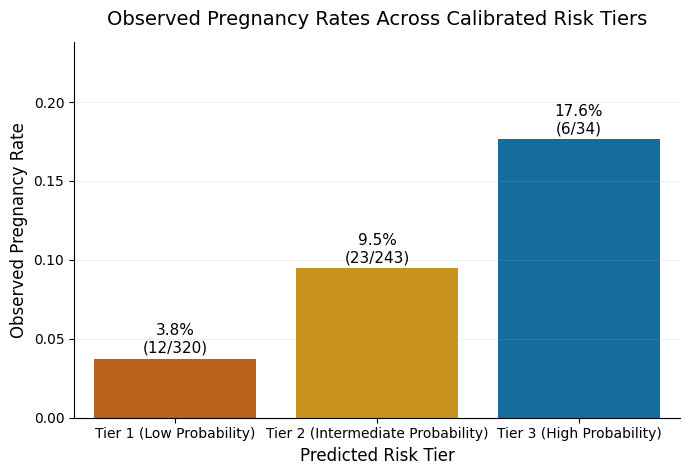


Calibration-set Risk Tier Summary:
                           Risk_Tier  Total_Cycles  Actual_Pregnancies  \
0           Tier 1 (Low Probability)           402                  14   
1  Tier 2 (Intermediate Probability)           256                  24   
2          Tier 3 (High Probability)            47                   9   

   Avg_Predicted_Prob  Min_Predicted_Prob  Max_Predicted_Prob  \
0            0.034826            0.000000            0.045802   
1            0.093750            0.062500            0.100962   
2            0.191489            0.162162            1.000000   

   Observed_Pregnancy_Rate  Predicted_minus_Observed      Dataset  
0                 0.034826             -1.742176e-09  Calibration  
1                 0.093750              0.000000e+00  Calibration  
2                 0.191489              6.975012e-09  Calibration  

Test-set Risk Tier Summary:
                           Risk_Tier  Total_Cycles  Actual_Pregnancies  \
0           Tier 1 (Low Probabi

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Risk Tier Analysis
# Final calibrated model
# FIX: ใช้ percentile-based cutoffs จาก test set distribution
# ==========================================

clinical_dir = FIGURE_DIR / "clinical"
clinical_dir.mkdir(parents=True, exist_ok=True)

required_objects = [
    'X_cal', 'y_cal', 'xgb_for_cal', 'iso_reg',
    'X_test_final', 'y_test', 'test_info'
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise ValueError(f"{obj_name} not found. Please run the calibration block first.")

# --------------------------------
# 1) Calibrated probabilities
# --------------------------------
cal_probs_raw        = xgb_for_cal.predict_proba(X_cal)[:, 1]
cal_probs_calibrated = np.clip(iso_reg.predict(cal_probs_raw), 0, 1)

test_probs_raw        = xgb_for_cal.predict_proba(X_test_final)[:, 1]
test_probs_calibrated = np.clip(iso_reg.predict(test_probs_raw), 0, 1)

tier_labels = [
    'Tier 1 (Low Probability)',
    'Tier 2 (Intermediate Probability)',
    'Tier 3 (High Probability)'
]

# --------------------------------
# 2) Percentile-based cutoffs จาก test set distribution
# แบ่ง 3 กลุ่มเท่าๆ กัน แล้วดู observed pregnancy rate
# --------------------------------
c1 = float(np.percentile(test_probs_calibrated, 33))
c2 = float(np.percentile(test_probs_calibrated, 67))
cutoff_method = f"percentile-based (33rd={c1:.4f}, 67th={c2:.4f})"

print(f"Cutoff method: {cutoff_method}")
print(f"c1 = {c1:.6f}, c2 = {c2:.6f}")
print()
print(">>> IMPORTANT: verify กับ app.py")
print(f"    PW_LOW_CUTOFF  = {c1:.6f}  (app.py hardcoded: 0.045802)")
print(f"    PW_HIGH_CUTOFF = {c2:.6f}  (app.py hardcoded: 0.100962)")

mismatch_low  = abs(c1 - 0.045802) > 1e-4
mismatch_high = abs(c2 - 0.100962) > 1e-4
if mismatch_low or mismatch_high:
    print("\n⚠️  MISMATCH — ต้องอัปเดต app.py ก่อน deploy")
    print(f"    PW_LOW_CUTOFF  = {c1:.6f}")
    print(f"    PW_HIGH_CUTOFF = {c2:.6f}")
else:
    print("\n✅ Cutoffs ตรงกับ app.py")

# --------------------------------
# 3) Calibration-set tiers
# --------------------------------
risk_cal_df = pd.DataFrame({
    'Predicted_Prob': cal_probs_calibrated,
    'Actual_Result':  y_cal.values
})

risk_cal_df['Risk_Tier'] = pd.cut(
    risk_cal_df['Predicted_Prob'],
    bins=[-np.inf, c1, c2, np.inf],
    labels=tier_labels,
    include_lowest=True
)

# --------------------------------
# 4) Calibration-set summary
# --------------------------------
cal_tier_summary = (
    risk_cal_df
    .groupby('Risk_Tier', observed=False)
    .agg(
        Total_Cycles=('Actual_Result', 'count'),
        Actual_Pregnancies=('Actual_Result', 'sum'),
        Avg_Predicted_Prob=('Predicted_Prob', 'mean'),
        Min_Predicted_Prob=('Predicted_Prob', 'min'),
        Max_Predicted_Prob=('Predicted_Prob', 'max')
    )
    .reset_index()
)
cal_tier_summary['Observed_Pregnancy_Rate']  = (
    cal_tier_summary['Actual_Pregnancies'] / cal_tier_summary['Total_Cycles']
)
cal_tier_summary['Predicted_minus_Observed'] = (
    cal_tier_summary['Avg_Predicted_Prob'] - cal_tier_summary['Observed_Pregnancy_Rate']
)
cal_tier_summary['Dataset'] = 'Calibration'

# --------------------------------
# 5) Apply tier logic to test set
# --------------------------------
risk_df = test_info.copy()
risk_df['Predicted_Prob'] = test_probs_calibrated
risk_df['Actual_Result']  = y_test
risk_df = risk_df.dropna(subset=['Predicted_Prob', 'Actual_Result']).copy()

risk_df['Risk_Tier'] = pd.cut(
    risk_df['Predicted_Prob'],
    bins=[-np.inf, c1, c2, np.inf],
    labels=tier_labels,
    include_lowest=True
)

# --------------------------------
# 6) Test-set summary
# --------------------------------
tier_summary = (
    risk_df
    .groupby('Risk_Tier', observed=False)
    .agg(
        Total_Cycles=('Actual_Result', 'count'),
        Actual_Pregnancies=('Actual_Result', 'sum'),
        Avg_Predicted_Prob=('Predicted_Prob', 'mean'),
        Min_Predicted_Prob=('Predicted_Prob', 'min'),
        Max_Predicted_Prob=('Predicted_Prob', 'max')
    )
    .reset_index()
)

if 'HN' in risk_df.columns:
    patient_counts = (
        risk_df
        .groupby('Risk_Tier', observed=False)['HN']
        .nunique()
        .reset_index(name='Unique_Patients')
    )
    tier_summary = tier_summary.merge(patient_counts, on='Risk_Tier', how='left')

tier_summary['Observed_Pregnancy_Rate']  = (
    tier_summary['Actual_Pregnancies'] / tier_summary['Total_Cycles']
)
tier_summary['Predicted_minus_Observed'] = (
    tier_summary['Avg_Predicted_Prob'] - tier_summary['Observed_Pregnancy_Rate']
)
tier_summary['Risk_Tier'] = pd.Categorical(
    tier_summary['Risk_Tier'], categories=tier_labels, ordered=True
)
tier_summary = tier_summary.sort_values('Risk_Tier').reset_index(drop=True)
tier_summary['Dataset'] = 'Test'

# --------------------------------
# 7) Save tables
# --------------------------------
cal_tier_summary.to_excel(
    REPORT_DIR / 'Risk_Tier_Summary_CalibrationSet_Calibrated.xlsx', index=False
)
tier_summary.to_excel(
    REPORT_DIR / 'Risk_Tier_Summary_FinalModel_Calibrated.xlsx', index=False
)
risk_df.to_excel(
    REPORT_DIR / 'Risk_Tier_Assignments_TestSet_Calibrated.xlsx', index=False
)

# --------------------------------
# 8) Plot
# --------------------------------
tier_colors = ['#d55e00', '#e69f00', '#0072b2']

fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
ax.set_facecolor('white')

sns.barplot(
    x='Risk_Tier', y='Observed_Pregnancy_Rate',
    data=tier_summary, palette=tier_colors, ax=ax
)

ax.set_title(
    'Observed Pregnancy Rates Across Calibrated Risk Tiers',
    fontsize=14, pad=12
)
ax.set_ylabel('Observed Pregnancy Rate', fontsize=12)
ax.set_xlabel('Predicted Risk Tier', fontsize=12)

ymax = tier_summary['Observed_Pregnancy_Rate'].max()
ax.set_ylim(0, max(0.05, ymax * 1.35))

for i, row in tier_summary.iterrows():
    label = (
        f"{row['Observed_Pregnancy_Rate']:.1%}\n"
        f"({int(row['Actual_Pregnancies'])}/{int(row['Total_Cycles'])})"
    )
    ax.text(i, row['Observed_Pregnancy_Rate'] + 0.002, label,
            ha='center', va='bottom', fontsize=11)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.grid(axis='y', alpha=0.18)
plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(
    clinical_dir / 'Risk_Tier_Analysis_FinalModel_Calibrated.png',
    dpi=300, bbox_inches='tight', facecolor='white'
)
plt.show()
plt.close()

# --------------------------------
# 9) Print summaries
# --------------------------------
print("\nCalibration-set Risk Tier Summary:")
print(cal_tier_summary)

print("\nTest-set Risk Tier Summary:")
print(tier_summary)

test_rates   = tier_summary['Observed_Pregnancy_Rate'].values
is_monotonic = np.all(np.diff(test_rates) > 0)
print(f"\nMonotonic increase across test tiers: {is_monotonic}")

print("\nRisk tier analysis complete.")

### Decision Curve Analysis (DCA)

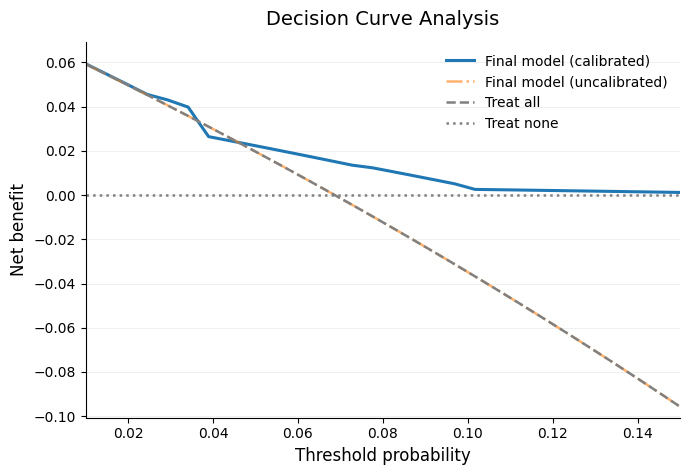


DCA complete.


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# Decision Curve Analysis
# Final calibrated model
# ==========================================

dca_dir = FIGURE_DIR / "dca"
dca_dir.mkdir(parents=True, exist_ok=True)

thresholds = np.linspace(0.01, 0.15, 30)

required_objects = ['y_test', 'test_probs_raw', 'test_probs_calibrated']
for obj_name in required_objects:
    if obj_name not in globals():
        raise ValueError(f"{obj_name} not found. Run the calibration block first.")

# -----------------------------
# Net benefit calculations
# -----------------------------
nb_model_raw = [calculate_net_benefit(y_test, test_probs_raw, t) for t in thresholds]
nb_model_cal = [calculate_net_benefit(y_test, test_probs_calibrated, t) for t in thresholds]
nb_all       = [calculate_net_benefit(y_test, np.ones(len(y_test)), t) for t in thresholds]
nb_none      = [0.0] * len(thresholds)

# -----------------------------
# Save table
# -----------------------------
dca_df = pd.DataFrame({
    'Threshold':              thresholds,
    'Net_Benefit_Raw':        nb_model_raw,
    'Net_Benefit_Calibrated': nb_model_cal,
    'Treat_All':              nb_all,
    'Treat_None':             nb_none
})

dca_df.to_excel(REPORT_DIR / 'DCA_Analysis_Final_Model.xlsx', index=False)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
ax.set_facecolor('white')

ax.plot(
    thresholds, nb_model_cal,
    linewidth=2.2,
    label='Final model (calibrated)'
)

ax.plot(
    thresholds, nb_model_raw,
    linewidth=1.8, linestyle='-.', alpha=0.6,
    label='Final model (uncalibrated)'
)

ax.plot(
    thresholds, nb_all,
    color='gray', linestyle='--', linewidth=1.8,
    label='Treat all'
)

ax.plot(
    thresholds, nb_none,
    color='gray', linestyle=':', linewidth=1.8,
    label='Treat none'
)

ax.set_xlabel('Threshold probability', fontsize=12)
ax.set_ylabel('Net benefit', fontsize=12)
ax.set_title('Decision Curve Analysis', fontsize=14, pad=12)

ax.set_xlim(0.01, 0.15)

ymin = min(np.nanmin(nb_model_raw), np.nanmin(nb_model_cal), np.nanmin(nb_all), 0)
ymax = max(np.nanmax(nb_model_raw), np.nanmax(nb_model_cal), np.nanmax(nb_all), 0)
ax.set_ylim(ymin - 0.005, ymax + 0.01)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.grid(axis='y', alpha=0.18)
ax.legend(frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(
    dca_dir / 'DCA_Final_Model.png',
    dpi=300, bbox_inches='tight', facecolor='white'
)

plt.show()
plt.close()

print("\nDCA complete.")

In [43]:
import joblib
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss, roc_curve
)

PROJECT_ROOT = Path.cwd().parent
REPORT_DIR   = PROJECT_ROOT / "reports" / "tables"

cal_df = pd.read_excel(
    REPORT_DIR / "Calibration_Test_Probabilities_Final_XGBoost_Baseline.xlsx"
)

y_test                = cal_df["y_true"].values
test_probs_raw        = cal_df["prob_raw"].values
test_probs_calibrated = cal_df["prob_calibrated"].values

print(f"Loaded: {len(y_test)} samples, {int(y_test.sum())} positives")

# หา threshold จาก full test set ก่อน (Youden บน calibrated)
threshold_df = pd.read_excel(REPORT_DIR / "calibration_threshold.xlsx")
THRESHOLD = float(threshold_df["threshold"].iloc[0])
print(f"Fixed threshold (from cal set): {THRESHOLD:.6f}")
print(f"Source: {threshold_df['source'].iloc[0]}")
print(f"Fixed threshold (Youden): {THRESHOLD:.4f}")


def bootstrap_ci(y_true, y_prob_raw, y_prob_cal, threshold,
                 n_bootstrap=1000, random_state=42):
    rng = np.random.RandomState(random_state)

    metrics = {
        "ROC-AUC":                  [],
        "PR-AUC":                   [],
        "Brier Score (raw)":        [],
        "Brier Score (calibrated)": [],
        "Sensitivity":              [],
        "Specificity":              [],
        "NPV":                      [],
        "PPV":                      [],
    }

    for _ in range(n_bootstrap):
        idx    = rng.choice(len(y_true), size=len(y_true), replace=True)
        yt     = y_true[idx]
        yp_raw = y_prob_raw[idx]
        yp_cal = y_prob_cal[idx]

        if yt.sum() == 0 or yt.sum() == len(yt):
            continue

        y_pred = (yp_cal >= threshold).astype(int)

        tp = ((yt == 1) & (y_pred == 1)).sum()
        tn = ((yt == 0) & (y_pred == 0)).sum()
        fp = ((yt == 0) & (y_pred == 1)).sum()
        fn = ((yt == 1) & (y_pred == 0)).sum()

        metrics["ROC-AUC"].append(roc_auc_score(yt, yp_raw))
        metrics["PR-AUC"].append(average_precision_score(yt, yp_raw))
        metrics["Brier Score (raw)"].append(brier_score_loss(yt, yp_raw))
        metrics["Brier Score (calibrated)"].append(brier_score_loss(yt, yp_cal))
        metrics["Sensitivity"].append(tp / (tp + fn) if (tp + fn) > 0 else np.nan)
        metrics["Specificity"].append(tn / (tn + fp) if (tn + fp) > 0 else np.nan)
        metrics["NPV"].append(tn / (tn + fn) if (tn + fn) > 0 else np.nan)
        metrics["PPV"].append(tp / (tp + fp) if (tp + fp) > 0 else np.nan)

    rows = []
    for name, vals in metrics.items():
        vals = [v for v in vals if not np.isnan(v)]
        m  = round(np.mean(vals), 4)
        lo = round(np.percentile(vals, 2.5), 4)
        hi = round(np.percentile(vals, 97.5), 4)
        rows.append({
            "Metric":       name,
            "Mean":         m,
            "95% CI Lower": lo,
            "95% CI Upper": hi,
            "95% CI":       f"{m} ({lo}–{hi})"
        })

    return pd.DataFrame(rows)


ci_table = bootstrap_ci(
    y_test, test_probs_raw, test_probs_calibrated,
    threshold=THRESHOLD
)

print("\n", ci_table[["Metric", "95% CI"]].to_string(index=False))

ci_table.to_csv(REPORT_DIR / "bootstrap_ci.csv", index=False)
ci_table.to_excel(REPORT_DIR / "bootstrap_ci.xlsx", index=False)
print("\nSaved bootstrap_ci.csv/.xlsx")

Loaded: 597 samples, 41 positives
Fixed threshold (from cal set): 0.100962
Source: calibration_set_youden_isotonic_30pct
Fixed threshold (Youden): 0.1010

                   Metric                 95% CI
                 ROC-AUC 0.6626 (0.5699–0.7422)
                  PR-AUC  0.1616 (0.0894–0.265)
       Brier Score (raw)  0.2193 (0.2117–0.227)
Brier Score (calibrated)   0.0627 (0.0464–0.08)
             Sensitivity 0.6109 (0.4615–0.7692)
             Specificity 0.6288 (0.5895–0.6685)
                     NPV 0.9562 (0.9356–0.9766)
                     PPV 0.1086 (0.0702–0.1498)

Saved bootstrap_ci.csv/.xlsx


In [11]:
### 10. Missing Data Report (TRIPOD)

import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "cycle_level_features.csv")

missing = pd.DataFrame({
    "N_missing": df.isnull().sum(),
    "Pct_missing": (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing[missing["N_missing"] > 0].sort_values("Pct_missing", ascending=False)

print(f"Total rows: {len(df)}")
print(f"Features with missing: {len(missing)}\n")
print(missing.to_string())

# save
REPORT_DIR = PROJECT_ROOT / "reports" / "tables"
missing.to_csv(REPORT_DIR / "missing_data_report.csv")
print("\nSaved missing_data_report.csv")

Total rows: 2945
Features with missing: 16

                                N_missing  Pct_missing
Unnamed: 57                          2944        99.97
Unnamed: 56                          2942        99.90
E2_Baseline                            41         1.39
FSH_Baseline                           39         1.32
LH_Baseline                            39         1.32
Age_FSH_Interaction                    39         1.32
PRL_Baseline                           38         1.29
Menstrual_Duration_Days                 3         0.10
Cycle_Day                               2         0.07
Ovulatory_Factors                       1         0.03
Menstrual_Interval_Days                 1         0.03
Dysmenorrhea                            1         0.03
Pre_TPMSC                               1         0.03
First_Normal_Morpho                     1         0.03
Gynecological_Surgical_History          1         0.03
Ratio_TPMSC                             1         0.03

Saved missing_data_r

In [29]:
df_origin = pd.read_excel(
    PROJECT_ROOT / "data" / "raw" / "final_coding.xlsx",
    sheet_name="final"
)

cycle_per_patient = df_origin.groupby("HN")["Cycle_Number"].max()

print("Distribution of max cycles per patient:")
print(cycle_per_patient.value_counts().sort_index())
print(f"\nMax cycles anyone did: {cycle_per_patient.max()}")
print(f"Patients who did > 3 cycles: {(cycle_per_patient > 3).sum()}")
print(f"Patients who did > 5 cycles: {(cycle_per_patient > 5).sum()}")
print(f"Total patients: {len(cycle_per_patient)}")

Distribution of max cycles per patient:
Cycle_Number
1     798
2     585
3     249
4      81
5      39
6      11
7       2
8       2
9       2
12      1
14      1
15      2
Name: count, dtype: int64

Max cycles anyone did: 15
Patients who did > 3 cycles: 141
Patients who did > 5 cycles: 21
Total patients: 1773


In [3]:
# ดูทุก step ว่าหายไปเท่าไหร่
df_raw = pd.read_excel(
    PROJECT_ROOT / "data" / "raw" / "final_coding.xlsx",
    sheet_name="final"
)

print("=== Patient Flow ===")
print(f"1. Raw data (all cycles):        {len(df_raw)} cycles, {df_raw['HN'].nunique()} patients")

# หลัง filter cycle 1-3
df_c3 = df_raw[pd.to_numeric(df_raw["Cycle_Number"], errors="coerce").isin([1,2,3])]
print(f"2. After filter cycle 1–3:       {len(df_c3)} cycles, {df_c3['HN'].nunique()} patients")

# หลัง drop missing outcome
df_c3_clean = df_c3.dropna(subset=["Result"])
print(f"3. After drop missing outcome:   {len(df_c3_clean)} cycles, {df_c3_clean['HN'].nunique()} patients")

# ที่เข้า model จริง
df_model = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "cycle_level_features.csv")
print(f"4. Final dataset (into model):   {len(df_model)} cycles, {df_model['HN'].nunique()} patients")

print(f"\n=== Excluded ===")
print(f"Cycle > 3 excluded:   {len(df_raw) - len(df_c3)} cycles")
print(f"Missing outcome:      {len(df_c3) - len(df_c3_clean)} cycles")

=== Patient Flow ===
1. Raw data (all cycles):        3161 cycles, 1773 patients
2. After filter cycle 1–3:       2945 cycles, 1761 patients
3. After drop missing outcome:   2945 cycles, 1761 patients
4. Final dataset (into model):   2945 cycles, 1761 patients

=== Excluded ===
Cycle > 3 excluded:   216 cycles
Missing outcome:      0 cycles


In [4]:
import pandas as pd
import numpy as np
from scipy import stats
from pathlib import Path
import re

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "cycle_level_features.csv"

df = pd.read_csv(DATA_PATH)
df.columns = [re.sub(r"[\[\]<>]", "_", str(col)).replace(" ", "_") for col in df.columns]

preg = df[df['Result'] == 1]
non_preg = df[df['Result'] == 0]

print(f"Total: {len(df)} | Pregnant: {len(preg)} ({len(preg)/len(df)*100:.1f}%) | Non-pregnant: {len(non_preg)} ({len(non_preg)/len(df)*100:.1f}%)")

# ==========================================
# Check normality first
# ==========================================
vars_cont = [
    'Age_Female', 'Body_Mass_Index', 'Menstrual_Interval_Days',
    'Total_infertile_duration',
    'First_Count', 'First_Progressive_Motile', 'First_TPMSC',
    'Pre_Count', 'Pre_TPMSC',
    'Post_Count', 'Post_TPMSC',
    'Mature_Follicle_Count', 'Endometrium_Thickness',
    'Cycle_Day'
]

vars_cat = [
    'Infertility_Type', 'Cycle_Number',
    'Uterine_Factors', 'Ovulatory_Factors',
    'Tubal_Factors', 'Cervical_Factors',
    'Endometriosis_Factors', 'Gynecological_Surgical_History'
]

print("\n=== Normality Check (Shapiro-Wilk, sample n=500) ===")
normal_vars = []
for var in vars_cont:
    if var not in df.columns:
        continue
    sample = df[var].dropna().sample(min(500, df[var].notna().sum()), random_state=42)
    _, pval = stats.shapiro(sample)
    is_normal = pval > 0.05
    if is_normal:
        normal_vars.append(var)
    print(f"  {var:<40} p={pval:.4f} {'→ Normal' if is_normal else '→ Non-normal'}")

# ==========================================
# Build Table 1 — median (IQR) for non-normal
# mean ± SD for normal
# ==========================================
rows = []

for var in vars_cont:
    if var not in df.columns:
        continue
    
    overall = df[var].dropna()
    p_vals  = preg[var].dropna()
    np_vals = non_preg[var].dropna()
    
    # Mann-Whitney U test for all (more appropriate for clinical data)
    if len(p_vals) > 1 and len(np_vals) > 1:
        _, pval = stats.mannwhitneyu(p_vals, np_vals, alternative='two-sided')
        pval_str = f"{pval:.3f}" if pval >= 0.001 else "<0.001"
        sig = "**" if pval < 0.05 else ""
    else:
        pval_str = "N/A"
        sig = ""
    
    n_miss = df[var].isna().sum()
    miss_str = f" ({n_miss} missing)" if n_miss > 0 else ""
    
    # Normal → mean ± SD / Non-normal → median (IQR)
    if var in normal_vars:
        fmt = "mean ± SD"
        overall_str = f"{overall.mean():.2f} ± {overall.std():.2f}"
        p_str       = f"{p_vals.mean():.2f} ± {p_vals.std():.2f}"
        np_str      = f"{np_vals.mean():.2f} ± {np_vals.std():.2f}"
    else:
        fmt = "median (IQR)"
        overall_str = f"{overall.median():.2f} ({overall.quantile(0.25):.2f}–{overall.quantile(0.75):.2f})"
        p_str       = f"{p_vals.median():.2f} ({p_vals.quantile(0.25):.2f}–{p_vals.quantile(0.75):.2f})"
        np_str      = f"{np_vals.median():.2f} ({np_vals.quantile(0.25):.2f}–{np_vals.quantile(0.75):.2f})"
    
    rows.append({
        'Variable': f"{var}{miss_str}",
        'Format': fmt,
        'Overall (n=2945)': overall_str,
        'Pregnant (n=183)': p_str,
        'Non-pregnant (n=2762)': np_str,
        'p-value': f"{sig}{pval_str}{sig}"
    })

# --- Categorical ---
for var in vars_cat:
    if var not in df.columns:
        continue
    
    ct = pd.crosstab(df[var], df['Result'])
    try:
        _, pval, _, _ = stats.chi2_contingency(ct)
        pval_str = f"{pval:.3f}" if pval >= 0.001 else "<0.001"
        sig = "**" if pval < 0.05 else ""
    except:
        pval_str = "N/A"
        sig = ""
    
    n_miss = df[var].isna().sum()
    miss_str = f" ({n_miss} missing)" if n_miss > 0 else ""
    
    if var == 'Cycle_Number':
        for i, val in enumerate(sorted(df[var].dropna().unique())):
            n_tot = (df[var] == val).sum()
            n_p   = (preg[var] == val).sum()
            n_np  = (non_preg[var] == val).sum()
            rows.append({
                'Variable': f"  Cycle {int(val)}",
                'Format': 'n (%)',
                'Overall (n=2945)': f"{n_tot} ({n_tot/len(df)*100:.1f}%)",
                'Pregnant (n=183)': f"{n_p} ({n_p/len(preg)*100:.1f}%)",
                'Non-pregnant (n=2762)': f"{n_np} ({n_np/len(non_preg)*100:.1f}%)",
                'p-value': f"{sig}{pval_str}{sig}" if i == 0 else ""
            })
    elif var == 'Infertility_Type':
        # 0 = primary, 1 = secondary
        for i, (val, label) in enumerate([(0, 'Primary'), (1, 'Secondary')]):
            n_tot = (df[var] == val).sum()
            n_p   = (preg[var] == val).sum()
            n_np  = (non_preg[var] == val).sum()
            rows.append({
                'Variable': f"  {label}",
                'Format': 'n (%)',
                'Overall (n=2945)': f"{n_tot} ({n_tot/len(df)*100:.1f}%)",
                'Pregnant (n=183)': f"{n_p} ({n_p/len(preg)*100:.1f}%)",
                'Non-pregnant (n=2762)': f"{n_np} ({n_np/len(non_preg)*100:.1f}%)",
                'p-value': f"{sig}{pval_str}{sig}" if i == 0 else ""
            })
    else:
        n_tot = (df[var] == 1).sum()
        n_p   = (preg[var] == 1).sum()
        n_np  = (non_preg[var] == 1).sum()
        rows.append({
            'Variable': f"{var}{miss_str}",
            'Format': 'n (%)',
            'Overall (n=2945)': f"{n_tot} ({n_tot/len(df)*100:.1f}%)",
            'Pregnant (n=183)': f"{n_p} ({n_p/len(preg)*100:.1f}%)",
            'Non-pregnant (n=2762)': f"{n_np} ({n_np/len(non_preg)*100:.1f}%)",
            'p-value': f"{sig}{pval_str}{sig}"
        })

# ==========================================
# Display
# ==========================================
table1 = pd.DataFrame(rows)

print(f"\n{'Variable':<45} {'Format':<15} {'Overall':>25} {'Pregnant':>25} {'Non-pregnant':>25} {'p':>10}")
print("-"*150)

for _, row in table1.iterrows():
    print(f"{row['Variable']:<45} {row['Format']:<15} {row['Overall (n=2945)']:>25} {row['Pregnant (n=183)']:>25} {row['Non-pregnant (n=2762)']:>25} {row['p-value']:>10}")

# ==========================================
# Save
# ==========================================
REPORT_DIR = PROJECT_ROOT / "reports" / "tables"
table1.to_excel(REPORT_DIR / "Table1_Baseline_Characteristics_Final.xlsx", index=False)
print("\nSaved to Table1_Baseline_Characteristics_Final.xlsx ✅")

# Footnote reminder
print("\n--- Footnote for paper ---")
print("Continuous variables: reported as mean ± SD (normal) or median (IQR) (non-normal)")
print("Categorical variables: reported as n (%)")
print("Comparisons: Mann-Whitney U test (continuous), Chi-square test (categorical)")
print("** p < 0.05")

Total: 2945 | Pregnant: 183 (6.2%) | Non-pregnant: 2762 (93.8%)

=== Normality Check (Shapiro-Wilk, sample n=500) ===
  Age_Female                               p=0.0016 → Non-normal
  Body_Mass_Index                          p=0.0000 → Non-normal
  Menstrual_Interval_Days                  p=0.0000 → Non-normal
  Total_infertile_duration                 p=0.0000 → Non-normal
  First_Count                              p=0.0000 → Non-normal
  First_Progressive_Motile                 p=0.0000 → Non-normal
  First_TPMSC                              p=0.0000 → Non-normal
  Pre_Count                                p=0.0000 → Non-normal
  Pre_TPMSC                                p=0.0000 → Non-normal
  Post_Count                               p=0.0000 → Non-normal
  Post_TPMSC                               p=0.0000 → Non-normal
  Mature_Follicle_Count                    p=0.0000 → Non-normal
  Endometrium_Thickness                    p=0.0001 → Non-normal
  Cycle_Day                          